# 1.

In [193]:
import os
import math
import torch
import numpy as np
import pandas as pd
import pickle, json
import seaborn as sns
import yfinance as yf
import umap as umap_lib
import matplotlib.pyplot as plt

from pathlib import Path
from talib import abstract
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from config import ConditioningConfig, DataEngineeringConfig
from utils import (
    AnnualSeasonalScaler,
    create_scaler,
    transform_windows_x, inverse_transform_windows_x,
    transform_windows_cond, inverse_transform_windows_cond,
    WindowDataset, make_dataloaders,
    save_data, load_data, build_datasets, load_and_make_dataloaders, verify_roundtrip,
)


In [ ]:
cond_cfg = ConditioningConfig(
    use_cyclical_time = True,
    cyclical_time = "weekday",
)

cfg = DataEngineeringConfig(
    name = "trial01",
    group_name = "set_index",
    subgroup_name = "set_idx50",
    description = "Default configuration for data engineering",

    symbols = [
"ADVANC.BK", "AOT.BK", "BANPU.BK", "BBL.BK", "BDMS.BK", "BEM.BK", "BH.BK", "BJC.BK", "BTS.BK", "CENTEL.BK", "CPALL.BK", "CPF.BK", "CPN.BK", "DELTA.BK", "EGCO.BK", "GLOBAL.BK", "HMPRO.BK", "IRPC.BK", "KBANK.BK", "KKP.BK", "KTB.BK", "KTC.BK", "LH.BK", "MINT.BK", "PTT.BK", "PTTEP.BK", "RATCH.BK", "SCC.BK", "TCAP.BK", "TISCO.BK", "TOP.BK", "TRUE.BK", "TU.BK"
        ],
    interval = "1d",

    train_period = ("2010-01-01", "2018-12-31"),
    val_period = ("2019-01-01", "2020-12-31"),
    test_period = ("2021-01-01", "2025-12-31"),

    window_size = 20,
    window_stride = 1,
    batch_sizes = {"train": 64, "val": 64, "test": 1},

    random_seed = 72,
    scaler_x="standard",  # Options: 'standard', 'robust', 'minmax', 'annual_seasonal', None
    scaler_cond="robust",  # Options: 'standard', 'robust', 'minmax', None
)

print(f"Config      : {cfg.name}")
print(f"Description : {cfg.description}")
print(f"Symbols     : {len(cfg.symbols)} assets")
print(f"Train       : {cfg.train_period[0]} → {cfg.train_period[1]}")
print(f"Val         : {cfg.val_period[0]}   → {cfg.val_period[1]}")
print(f"Test        : {cfg.test_period[0]}  → {cfg.test_period[1]}")
print(f"Window      : {cfg.window_size}")
print(f"Window Strides: {cfg.window_strides}")
print(f"Ind. shift  : {cfg.conditioning.indicator_shift}  (auto = window_size)")
print(f"Indicators  : {[ind.name for ind in cfg.conditioning.indicators]}")
print(f"Save dir    : {cfg.save_dir}")
print(f"Analysis dir : {cfg.analysis_dir}")

Config      : trial01_w50_assets33_scaler-x_standard_scaler-condrobust
Description : Default configuration for data engineering | Window Size: 50, Indicator Shift: 50, Assets: 33 | Train: ('2010-01-01', '2018-12-31'), Val: ('2019-01-01', '2020-12-31'), Test: ('2021-01-01', '2025-12-31') | Conditioning: conditioning_config with 13 indicators
Symbols     : 33 assets
Train       : 2010-01-01 → 2018-12-31
Val         : 2019-01-01   → 2020-12-31
Test        : 2021-01-01  → 2025-12-31
Window      : 50
Window Strides: {'train': 1, 'val': 1, 'test': 50}
Ind. shift  : 50  (auto = window_size)
Indicators  : ['MACD', 'ADX', 'SAR', 'EMA', 'EMA', 'EMA', 'RSI', 'STOCH', 'CCI', 'ATR', 'BBANDS', 'OBV', 'ADOSC']
Save dir    : /home/narodom.y@FUSION.LAB/research/01_processed/set_index/set_idx50/trial01_w50_assets33_scaler-x_standard_scaler-condrobust
Analysis dir : /home/narodom.y@FUSION.LAB/research/01_processed/set_index/set_idx50/trial01_w50_assets33_scaler-x_standard_scaler-condrobust/analysis


In [195]:
if not os.path.exists(cfg.save_dir):
    os.makedirs(cfg.save_dir)

if not os.path.exists(cfg.analysis_dir):
    os.makedirs(cfg.analysis_dir)

if not os.path.exists(cfg.analysis_figure_dir):
    os.makedirs(cfg.analysis_figure_dir)

if not os.path.exists(cfg.analysis_table_dir):
    os.makedirs(cfg.analysis_table_dir)

# 2. Download & Clean Raw Data

In [196]:
def plot_missing_data(df: pd.DataFrame, assets: list, column: str, title: str = ""):
    prices = df[column]
    fig, axes = plt.subplots(len(assets), 1, figsize=(14, max(8, len(assets) * 1.2)))
    if title:
        fig.suptitle(title, fontsize=10, y=1.001)

    for ax, sym in zip(axes, assets):
        series = prices[sym]
        ax.plot(series.index, series.values, lw=0.8)
        nan_idx = series.index[series.isna()]
        if len(nan_idx):
            ax.scatter(nan_idx, [series.mean()] * len(nan_idx),
                       color="red", marker="x", s=40, zorder=5, label="NaN")
        ax.set_title(sym, fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    nan_counts = df[column].isna().sum()
    if nan_counts.any():
        print("NaN counts per asset:")
        print(nan_counts[nan_counts > 0].to_string())
    else:
        print("✓ No NaN values found.")


def process_missing_data(df: pd.DataFrame) -> pd.DataFrame:
    first_valid = df.notna().all(axis=1).idxmax()
    df = df.loc[first_valid:]
    df.ffill(inplace=True)
    return df


def summarize_split(name: str, df: pd.DataFrame):
    n_days   = len(df)
    n_assets = df.columns.get_level_values(1).nunique()
    d_start  = df.index[0].date()
    d_end    = df.index[-1].date()
    print(f"  {name:<6} │ {d_start} → {d_end} │ {n_days:>4} trading days │ {n_assets} assets")

def plot_missing_data(splits: dict, assets: list, column: str, title: str = ""):
    """
    splits : dict of {split_name: df}  e.g. {"train": df_train, "val": df_val, "test": df_test}
    assets : list of ticker symbols
    column : e.g. "Close"
    """
    import matplotlib.patches as mpatches

    SPLIT_COLORS = {"train": "#4C9BE8", "val": "#F5A623", "test": "#7ED321"}

    def get_series(df, col, sym):
        """Safe column access for both MultiIndex and flat DataFrames."""
        try:
            if isinstance(df.columns, pd.MultiIndex):
                if (col, sym) in df.columns:
                    return df[(col, sym)]
            else:
                if sym in df.columns:
                    return df[sym]
        except Exception:
            pass
        return None

    fig, axes = plt.subplots(len(assets), 1, figsize=(14, max(8, len(assets) * 1.2)))
    if title:
        fig.suptitle(title, fontsize=10, y=1.001)

    if len(assets) == 1:
        axes = [axes]

    nan_report = {split_name: {} for split_name in splits}

    for ax, sym in zip(axes, assets):
        has_any_data = False

        for split_name, df in splits.items():
            if df is None or df.empty:
                continue

            series = get_series(df, column, sym)
            if series is None or series.dropna().empty:
                nan_report[split_name][sym] = "missing"
                continue

            color = SPLIT_COLORS.get(split_name, "gray")
            has_any_data = True

            ax.plot(series.index, series.values, lw=0.8, color=color)
            ax.axvspan(series.index[0], series.index[-1], alpha=0.07, color=color)

            nan_idx = series.index[series.isna()]
            if len(nan_idx):
                ax.scatter(nan_idx, [series.mean()] * len(nan_idx),
                           color="red", marker="x", s=40, zorder=5)
                nan_report[split_name][sym] = len(nan_idx)

        if not has_any_data:
            ax.text(0.5, 0.5, "No data", transform=ax.transAxes,
                    ha="center", va="center", fontsize=7, color="red")

        ax.set_title(sym, fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(alpha=0.3)

    # Legend
    patches = [mpatches.Patch(color=c, label=n) for n, c in SPLIT_COLORS.items()]
    patches.append(plt.Line2D([0], [0], marker="x", color="red",
                               label="NaN", linestyle="None", markersize=6))
    fig.legend(handles=patches, loc="upper right", fontsize=8, ncol=4, framealpha=0.9)

    plt.tight_layout()
    plt.savefig(os.path.join(cfg.analysis_figure_dir, f"plot_missing_data_{column}.png"), dpi=200, bbox_inches='tight')
    plt.close()

    # NaN / missing summary
    print("\nNaN / missing summary:")
    any_issue = False
    for split_name, issues in nan_report.items():
        if issues:
            any_issue = True
            print(f"  [{split_name}]")
            for sym, val in issues.items():
                label = "missing (no data)" if val == "missing" else f"{val} NaN rows"
                print(f"    {sym:<16} {label}")
    if not any_issue:
        print("  ✓ No NaN values found.")

In [197]:
assets = cfg.symbols
interval = cfg.interval
splits = {
    "train": yf.download(assets, start=cfg.train_period[0], end=cfg.train_period[1], interval=interval),
    "val"  : yf.download(assets, start=cfg.val_period[0],   end=cfg.val_period[1],   interval=interval),
    "test" : yf.download(assets, start=cfg.test_period[0],  end=cfg.test_period[1],  interval=interval),
}

for split_name, df_split in splits.items():
    splits[split_name] = process_missing_data(df_split)

df_train = splits["train"]
df_val   = splits["val"]
df_test  = splits["test"]

print("── Data Summary ──────────────────────────────────────────────────────")
for name, df_s in splits.items():
    summarize_split(name, df_s)
print(f"  {'TOTAL':<6} │ {'':>27} │ {sum(len(d) for d in splits.values()):>4} trading days")
plot_missing_data(splits, assets, column="Close", title="SET50: Missing Data")

[*********************100%***********************]  33 of 33 completed
[*********************100%***********************]  33 of 33 completed
[*********************100%***********************]  33 of 33 completed


── Data Summary ──────────────────────────────────────────────────────
  train  │ 2010-01-04 → 2018-12-28 │ 2198 trading days │ 33 assets
  val    │ 2019-01-02 → 2020-12-30 │  487 trading days │ 33 assets
  test   │ 2021-01-04 → 2025-12-30 │ 1210 trading days │ 33 assets
  TOTAL  │                             │ 3895 trading days



NaN / missing summary:
  ✓ No NaN values found.


# 3. Feature Processing

## 3.1 OHLCV → Log-Return / Volume-Ratio conversion 
Convert a raw OHLCV MultiIndex DataFrame into a log-return DataFrame.
Transformation
- Open, High, Low, Close : log(P_t / P_{t-1})
- Volume                 : V_t / V_{t-1}  (volume ratio)
                           Volume = 0 on halt days → replaced with NaN
                           before shift so division never yields inf.
Notes
* Returns a *new* DataFrame — the original is never modified.
* Row t=0 is all-NaN (no previous price); callers should retain the
  original df to use as the seed for `log_return_to_ohlcv`.
* Columns keep the same MultiIndex structure (feat, sym).

Parameters
* df : pd.DataFrame
MultiIndex columns (price_field, symbol), e.g. ("Close", "PTT.BK").

Returns
* pd.DataFrame  — same index, same MultiIndex column structure.



Reverse log-return / volume-ratio back to raw OHLCV prices.
Reconstruction

- O/H/L/C : P_t = P_{t-1} * exp(lr_t),  P_0 taken from `df_seed`
- Volume  : V_t = V_{t-1} * ratio_t,     V_0 taken from `df_seed`
  
Parameters
* df_lr   : pd.DataFrame — log-return df produced by `ohlcv_to_log_return`.
          Must *not* include the seed row (row 0 of the original is NaN
          and was dropped); pass the slice starting at index 1.
* df_seed : pd.DataFrame — the original raw OHLCV df used to obtain the
          seed values (row at df_lr.index[0] - 1 day).  Typically this
          is df_train / df_val / df_test before conversion.
Returns
* pd.DataFrame — reconstructed OHLCV, MultiIndex (price_field, symbol),
               aligned to df_lr.index.

In [198]:
def ohlc_to_log_return(df: pd.DataFrame) -> pd.DataFrame:
    price_cols = ["Open", "High", "Low", "Close"]
    parts      = {}

    for col in price_cols:
        prices  = df.xs(col, level=0, axis=1)
        log_ret = np.log(prices / prices.shift(1))
        for sym in log_ret.columns:
            parts[(col, sym)] = log_ret[sym]

    result         = pd.DataFrame(parts, index=df.index)
    result.columns = pd.MultiIndex.from_tuples(result.columns)
    result.columns.names = df.columns.names
    result         = result.swaplevel(axis=1).sort_index(axis=1)
    return result


def log_return_to_ohlc(df_lr: pd.DataFrame, df_seed: pd.DataFrame) -> pd.DataFrame:
    price_cols = ["Open", "High", "Low", "Close"]
    syms       = df_lr.columns.get_level_values(0).unique().tolist()

    # Seed row: last date in df_seed strictly before df_lr starts
    before_mask = df_seed.index < df_lr.index[0]
    seed_date   = df_seed.index[before_mask][-1] if before_mask.any() else df_seed.index[0]
    seed_row    = df_seed.loc[seed_date]

    def get_seed(feat, sym):
        try:
            return float(seed_row[(feat, sym)])
        except KeyError:
            return float(seed_row[(sym, feat)])

    parts = {}

    for col in price_cols:
        lr_mat = df_lr.xs(col, level=1, axis=1)   # (T, n_syms)

        out = np.empty((len(lr_mat), len(syms)))
        for j, sym in enumerate(syms):
            p0        = get_seed(col, sym)
            out[:, j] = p0 * np.exp(np.cumsum(lr_mat[sym].values))

        df_price = pd.DataFrame(out, index=df_lr.index, columns=syms)
        for sym in syms:
            parts[(col, sym)] = df_price[sym]

    result         = pd.DataFrame(parts, index=df_lr.index)
    result.columns = pd.MultiIndex.from_tuples(result.columns)
    result         = result.swaplevel(axis=1).sort_index(axis=1)
    return result

## 3.2 Build log-return splits (originals preserved)

In [199]:
# Sort originals by date first (guarantees positional seed lookup is correct)
df_train = df_train.sort_index()
df_val   = df_val.sort_index()
df_test  = df_test.sort_index()

# Convert OHLC to log-return format for all splits
df_train_lr = ohlc_to_log_return(df_train)
df_val_lr   = ohlc_to_log_return(df_val)
df_test_lr  = ohlc_to_log_return(df_test)

# Drop the NaN seed row (t=0 has no previous price)
df_train_lr = df_train_lr.dropna()
df_val_lr   = df_val_lr.dropna()
df_test_lr  = df_test_lr.dropna()

print("── Log-Return Splits Summary ───────────────────────────────────────────────")
for name, df_orig, df_lr in [
    ("train", df_train, df_train_lr),
    ("val",   df_val,   df_val_lr),
    ("test",  df_test,  df_test_lr),
]:
    print(f"  {name:<6} │ original {len(df_orig):>4} rows → lr {len(df_lr):>4} rows "
          f"│ index aligned: {df_orig.index[-1] == df_lr.index[-1]}")

print(f"\nColumns (1 asset sample — {assets[0]}):")
print(df_train_lr.xs(assets[0], level=0, axis=1).columns.tolist())

── Log-Return Splits Summary ───────────────────────────────────────────────
  train  │ original 2198 rows → lr 2197 rows │ index aligned: True
  val    │ original  487 rows → lr  486 rows │ index aligned: True
  test   │ original 1210 rows → lr 1209 rows │ index aligned: True

Columns (1 asset sample — ADVANC.BK):
['Close', 'High', 'Low', 'Open']


In [200]:
# ── Round-trip sanity check ────────────────────────────────────────────────
df_reconstructed = log_return_to_ohlc(df_train_lr, df_train)

close_orig  = df_train.xs("Close", level=0, axis=1).loc[df_train_lr.index]
close_recon = df_reconstructed.xs("Close", level=1, axis=1)

print("orig  cols:", close_orig.columns.tolist()[:3])
print("recon cols:", close_recon.columns.tolist()[:3])
print("cols match:", (close_orig.columns == close_recon.columns).all())

max_err = (close_orig - close_recon).abs().max().max()
print(f"\nRound-trip max absolute error (Close): {max_err:.6e}  "
      f"{'✓ OK' if max_err < 1e-6 else '✗ CHECK'}")

# Check max absolute error per asset (ignoring column order)
(close_orig - close_recon.reindex(columns=close_orig.columns)).abs().max()

orig  cols: ['ADVANC.BK', 'AOT.BK', 'BANPU.BK']
recon cols: ['ADVANC.BK', 'AOT.BK', 'BANPU.BK']
cols match: True

Round-trip max absolute error (Close): 9.947598e-13  ✓ OK


Ticker
ADVANC.BK    6.821210e-13
AOT.BK       1.136868e-13
BANPU.BK     3.552714e-14
BBL.BK       5.968559e-13
BDMS.BK      1.705303e-13
BEM.BK       1.376677e-14
BH.BK        4.263256e-13
BJC.BK       2.984279e-13
BTS.BK       3.907985e-14
CENTEL.BK    3.836931e-13
CPALL.BK     1.421085e-13
CPF.BK       9.237056e-14
CPN.BK       3.694822e-13
DELTA.BK     3.286260e-14
EGCO.BK      9.947598e-13
GLOBAL.BK    4.263256e-14
HMPRO.BK     1.598721e-14
IRPC.BK      2.398082e-14
KBANK.BK     4.547474e-13
KKP.BK       5.684342e-14
KTB.BK       6.750156e-14
KTC.BK       7.105427e-14
LH.BK        1.332268e-14
MINT.BK      1.065814e-13
PTT.BK       2.131628e-13
PTTEP.BK     6.394885e-13
RATCH.BK     1.065814e-13
SCC.BK       6.821210e-13
TCAP.BK      7.815970e-14
TISCO.BK     2.060574e-13
TOP.BK       2.557954e-13
TRUE.BK      2.664535e-14
TU.BK        3.197442e-14
dtype: float64

In [201]:
def add_cyclical_time(df: pd.DataFrame, df_raw: pd.DataFrame, assets: list,
                      cycle: str = "weekday") -> pd.DataFrame:
    index = pd.to_datetime(df_raw.index)
    if cycle == "weekday":
        values, period, name = index.dayofweek % 5, 5, "weekday"
    else:
        raise ValueError(f"Unsupported cycle: {cycle}")

    base = pd.DataFrame(
        {f"{name}_sin": np.sin(2 * np.pi * values / period),
         f"{name}_cos": np.cos(2 * np.pi * values / period)},
        index=df_raw.index,
    )
    df_cyc = pd.concat([base.copy() for _ in assets], axis=1,
                       keys=assets).swaplevel(axis=1).sort_index(axis=1)
    return pd.concat([df, df_cyc], axis=1)

def add_volume(df: pd.DataFrame, df_raw: pd.DataFrame,
               assets: list) -> pd.DataFrame:
    """
    Column added: (asset, volume_lr)
    Volume source: df_raw (original OHLCV), log-return normalised.
    Halt days (vol == 0) are replaced with NaN before shifting
    so that log(0/x) never yields -inf.
    """
    vol = df_raw.xs("Volume", level=0, axis=1).loc[df.index]
    vol = vol.replace(0, np.nan)               # halt days → NaN
    vol_lr = np.log(vol / vol.shift(1))        # same as OHLC transform

    df_vol = pd.concat(
        [vol_lr[[sym]].rename(columns={sym: "volume_lr"})
         for sym in assets],
        axis=1, keys=assets
    ).swaplevel(axis=1).sort_index(axis=1)

    return pd.concat([df, df_vol], axis=1)

# --------------------------------------------------------------------------------------
def apply_normalization(series: pd.Series, norm_type: str,
                        period: int, close: pd.Series = None) -> pd.Series:
    if norm_type is None:
        return series
    if norm_type == "zscore":
        return (series - series.rolling(period).mean()) / series.rolling(period).std()
    elif norm_type == "minmax":
        lo = series.rolling(period).min()
        hi = series.rolling(period).max()
        return (series - lo) / (hi - lo + 1e-8)
    elif norm_type == "pct_change":
        return series.pct_change()
    elif norm_type == "distance_close":
        if close is None:
            raise ValueError("distance_close requires close prices")
        return (close - series) / (close + 1e-8)
    else:
        print(f"Warning: unknown norm_type '{norm_type}', returning original.")
        return series

def add_indicators(df: pd.DataFrame, df_raw: pd.DataFrame, assets: list, cfg) -> pd.DataFrame:
    parts = []
    for sym in assets:
        ohlcv = df_raw.loc[:, (slice(None), sym)].copy()
        ohlcv.columns = ohlcv.columns.get_level_values("Price")

        close = ohlcv["Close"]
        ohlcv_dict = {k.lower(): v.astype(float).values for k, v in ohlcv.items()}

        rows = {}
        for ind in cfg.indicators:
            try:
                func      = abstract.Function(ind.name)
                result    = func(ohlcv_dict, **ind.params)
                out_names = func.info["output_names"]
                period    = ind.params.get("timeperiod", 14)

                outputs = result    if isinstance(result, (tuple, list)) else [result]
                names   = out_names if isinstance(result, (tuple, list)) else \
                          ["_".join(str(v) for v in ind.params.values())]

                for arr, out in zip(outputs, names):
                    val  = pd.Series(arr, index=ohlcv.index)
                    val  = apply_normalization(val, ind.norm_type, period, close)
                    col  = f"{ind.name}_{out}"
                    if ind.norm_type:
                        col += f"_{ind.norm_type}"
                    rows[col] = val.shift(cfg.indicator_shift)

            except Exception as e:
                print(f"  ✗ {ind.name}/{sym}: {e}")

        parts.append(pd.DataFrame(rows, index=ohlcv.index))

    df_ind = pd.concat(parts, axis=1, keys=assets)
    df_ind.columns.names = ["Ticker", "Price"]
    df_ind = df_ind.swaplevel(axis=1).sort_index(axis=1)

    return pd.concat([df, df_ind], axis=1)

def build_cond(df_raw: pd.DataFrame, assets: list) -> pd.DataFrame:
    df = df_raw.iloc[:, :0].copy()
    df = add_cyclical_time(df, df_raw, assets)
    df = add_volume(df, df_raw, assets)
    df = add_indicators(df, df_raw, assets, cfg.conditioning)

    df.columns.names = df_raw.columns.names
    df = df.swaplevel(axis=1).sort_index(axis=1)
    df = df.rename_axis(columns={"Price": "Condition"})

    print(f"🔹 INDEX  -> Total Levels: {df.index.nlevels} | Names: {list(df.index.names)}")
    print(f"🔹 COLUMNS-> Total Levels: {df.columns.nlevels} | Names: {list(df.columns.names)}")
    print("-" * 60)

    rows_before = len(df)
    df_cleaned = df.dropna()
    rows_after = len(df_cleaned)
    print(f"  • Rows Before Drop: {rows_before:,}")
    print(f"  • Rows After Drop : {rows_after:,}")
    print(f"  • Total Dropped   : {rows_before - rows_after:,} rows")
    print("=" * 60)

    return df_cleaned

In [202]:
df_train_cond = build_cond(df_train, assets)
df_val_cond   = build_cond(df_val,   assets)
df_test_cond  = build_cond(df_test,  assets)

🔹 INDEX  -> Total Levels: 1 | Names: ['Date']
🔹 COLUMNS-> Total Levels: 2 | Names: ['Ticker', 'Condition']
------------------------------------------------------------
  • Rows Before Drop: 2,198
  • Rows After Drop : 1,921
  • Total Dropped   : 277 rows
🔹 INDEX  -> Total Levels: 1 | Names: ['Date']
🔹 COLUMNS-> Total Levels: 2 | Names: ['Ticker', 'Condition']
------------------------------------------------------------
  • Rows Before Drop: 487
  • Rows After Drop : 238
  • Total Dropped   : 249 rows
🔹 INDEX  -> Total Levels: 1 | Names: ['Date']
🔹 COLUMNS-> Total Levels: 2 | Names: ['Ticker', 'Condition']
------------------------------------------------------------
  • Rows Before Drop: 1,210
  • Rows After Drop : 824
  • Total Dropped   : 386 rows


In [203]:
print(df_train_lr.shape)
print(df_train_lr.index.names)
print(df_train_lr.columns.names)

print(df_train_cond.shape)
print(df_train_cond.index.names)
print(df_train_cond.columns.names)

(2197, 132)
['Date']
['Ticker', 'Price']
(1921, 693)
['Date']
['Ticker', 'Condition']


In [204]:
# ── train ──────────────────────────────────────────────────────────────────
common_index_train      = df_train_lr.index.intersection(df_train_cond.index)
df_train_lr_aligned     = df_train_lr.reindex(common_index_train)
df_train_cond_aligned   = df_train_cond.reindex(common_index_train)

# ── val ────────────────────────────────────────────────────────────────────
common_index_val        = df_val_lr.index.intersection(df_val_cond.index)
df_val_lr_aligned       = df_val_lr.reindex(common_index_val)
df_val_cond_aligned     = df_val_cond.reindex(common_index_val)

# ── test ───────────────────────────────────────────────────────────────────
common_index_test       = df_test_lr.index.intersection(df_test_cond.index)
df_test_lr_aligned      = df_test_lr.reindex(common_index_test)
df_test_cond_aligned    = df_test_cond.reindex(common_index_test)

print("🔹 AFTER ALIGNMENT SHAPE:")
print("df_train_lr_aligned  :", df_train_lr_aligned.shape)
print("df_train_cond_aligned:", df_train_cond_aligned.shape)
print("-" * 50)
print("df_val_lr_aligned    :", df_val_lr_aligned.shape)
print("df_val_cond_aligned  :", df_val_cond_aligned.shape)
print("-" * 50)
print("df_test_lr_aligned   :", df_test_lr_aligned.shape)
print("df_test_cond_aligned :", df_test_cond_aligned.shape)
print("-" * 50)
print("Index Match Check     :", df_train_lr_aligned.index.equals(df_train_cond_aligned.index))

🔹 AFTER ALIGNMENT SHAPE:
df_train_lr_aligned  : (1921, 132)
df_train_cond_aligned: (1921, 693)
--------------------------------------------------
df_val_lr_aligned    : (238, 132)
df_val_cond_aligned  : (238, 693)
--------------------------------------------------
df_test_lr_aligned   : (824, 132)
df_test_cond_aligned : (824, 693)
--------------------------------------------------
Index Match Check     : True


In [205]:
def plot_and_save_missing_data(df, target_name, category="Indicator", save_dir="my_plots"):
    try:
        data_to_plot = df.xs(target_name, level=1, axis=1)
    except KeyError:
        print(f"❌ Not Found '{target_name}' in DataFrame")
        return

    tickers = data_to_plot.columns
    fig, axes = plt.subplots(nrows=len(tickers), ncols=1, figsize=(12, 3 * len(tickers)), squeeze=False)

    for ax, ticker in zip(axes.flatten(), tickers):
        ax.plot(data_to_plot.index, data_to_plot[ticker], color='#1f77b4', label=f'{ticker}')

        nan_dates = data_to_plot[data_to_plot[ticker].isna()].index
        if len(nan_dates) > 0:
            ymin, ymax = ax.get_ylim()
            ax.vlines(x=nan_dates, ymin=ymin, ymax=ymax, color='red', alpha=0.4, linewidth=1.5)

        ax.set_title(f'{ticker} | {category}: {target_name}', fontsize=12, fontweight='bold')
        ax.legend(loc='upper left')
        ax.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()

    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    safe_category_name = category.lower().replace(" ", "_")
    filename = f"plot_{safe_category_name}_{target_name.lower().replace(' ', '_')}.png"
    full_path = os.path.join(save_dir, filename)

    plt.savefig(full_path, dpi=200, bbox_inches='tight')
    plt.close()

    print(f"✅ Saved plot for {category} '{target_name}' successfully at: {full_path}")

In [ ]:
plot_and_save_missing_data(df_train_cond_aligned,
                   target_name='volume_lr',
                   category="Indicator",
                   save_dir=cfg.analysis_figure_dir)

plot_and_save_missing_data(df_train_cond_aligned,
                   target_name='weekday_sin',
                   category="Indicator",
                   save_dir=cfg.analysis_figure_dir)

plot_and_save_missing_data(df_train_cond_aligned,
                   target_name='weekday_cos',
                   category="Indicator",
                   save_dir=cfg.analysis_figure_dir)

plot_and_save_missing_data(df_train_lr_aligned,
                   target_name='Close',
                   category="Log-Return",
                   save_dir=cfg.analysis_figure_dir)

✅ Saved plot for Indicator 'volume_lr' successfully at: /home/narodom.y@FUSION.LAB/research/01_processed/set_index/set_idx50/trial01_w50_assets33_scaler-x_standard_scaler-condrobust/analysis/figures/plot_indicator_volume_lr.png


✅ Saved plot for Indicator 'weekday_sin' successfully at: /home/narodom.y@FUSION.LAB/research/01_processed/set_index/set_idx50/trial01_w50_assets33_scaler-x_standard_scaler-condrobust/analysis/figures/plot_indicator_weekday_sin.png
✅ Saved plot for Indicator 'weekday_cos' successfully at: /home/narodom.y@FUSION.LAB/research/01_processed/set_index/set_idx50/trial01_w50_assets33_scaler-x_standard_scaler-condrobust/analysis/figures/plot_indicator_weekday_cos.png
✅ Saved plot for Log-Return 'Close' successfully at: /home/narodom.y@FUSION.LAB/research/01_processed/set_index/set_idx50/trial01_w50_assets33_scaler-x_standard_scaler-condrobust/analysis/figures/plot_log-return_close.png


# 4. Data Analysis

## 4.0  Setup — helpers & extra imports

In [ ]:
def aplot(fname: str) -> str:
    return os.path.join(cfg.analysis_figure_dir, f"{cfg.name}_{fname}")

def atable(fname: str) -> str:
    return os.path.join(cfg.analysis_table_dir, f"{cfg.name}_{fname}")

print(f"Config      : {cfg.name}")
print(f"Analysis    → {cfg.analysis_dir}")
print(f"  plots/    : {cfg.analysis_figure_dir}")
print(f"  tables/   : {cfg.analysis_table_dir}")

Config      : trial01_w50_assets33_scaler-x_standard_scaler-condrobust
Analysis    → /home/narodom.y@FUSION.LAB/research/01_processed/set_index/set_idx50/trial01_w50_assets33_scaler-x_standard_scaler-condrobust/analysis
  plots/    : /home/narodom.y@FUSION.LAB/research/01_processed/set_index/set_idx50/trial01_w50_assets33_scaler-x_standard_scaler-condrobust/analysis/figures
  tables/   : /home/narodom.y@FUSION.LAB/research/01_processed/set_index/set_idx50/trial01_w50_assets33_scaler-x_standard_scaler-condrobust/analysis/tables


## 4.1  Log-Return Distribution per Asset

In [ ]:
# Close log-returns from train split (already NaN-dropped in Section 3)
log_ret = df_train_lr.xs("Close", axis=1, level=1).copy()

stats_df = pd.DataFrame({
    "Mean"    : log_ret.mean(),
    "Std"     : log_ret.std(),
    "Skew"    : log_ret.skew(),
    "Kurt"    : log_ret.kurt(),
    "Min"     : log_ret.min(),
    "Max"     : log_ret.max(),
    "Sharpe"  : log_ret.mean() / log_ret.std() * np.sqrt(252),
    "Ann.Ret" : log_ret.mean() * 252,
    "Ann.Vol" : log_ret.std()  * np.sqrt(252),
}).round(6)

path = atable("4.1_return_stats.csv")
stats_df.to_csv(path)
print(f"✓ {os.path.basename(path)}")
print(stats_df.sort_values("Std", ascending=False).to_string())

n_assets = len(assets)
ncols = 4
nrows = math.ceil(n_assets / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
axes = axes.flatten()

for i, sym in enumerate(sorted(assets)):
    ax = axes[i]
    ret = log_ret[sym].dropna()
    mu, sigma = ret.mean(), ret.std()
    ax.hist(ret, bins=80, color="steelblue", alpha=0.7, density=True, edgecolor="none")
    ax.axvline(mu, color="gold", lw=1.2)
    for s in [1, -1]:
        ax.axvline(mu + s * 2 * sigma, color="tomato", lw=1, ls="--")
    ax.set_title(f"{sym}  μ={mu:.4f}  σ={sigma:.4f}\nskew={ret.skew():.2f}  kurt={ret.kurt():.2f}", fontsize=7.5)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.25)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Log-Return Distribution per Asset  (orange=±2σ | yellow=mean)", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(aplot("4.1_return_dist.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ {os.path.basename(aplot('4.1_return_dist.png'))}")

✓ trial01_w50_assets33_scaler-x_standard_scaler-condrobust_4.1_return_stats.csv
               Mean       Std      Skew       Kurt       Min       Max    Sharpe   Ann.Ret   Ann.Vol
Ticker                                                                                              
TRUE.BK    0.000490  0.029081 -0.164526   8.423293 -0.287682  0.180670  0.267352  0.123422  0.461646
KTC.BK     0.001543  0.027666 -0.506164  17.733372 -0.356675  0.227463  0.885394  0.388848  0.439181
BJC.BK     0.001172  0.024155  0.955562   7.467487 -0.110595  0.203665  0.770249  0.295353  0.383452
GLOBAL.BK  0.001488  0.023936  0.471623   3.699221 -0.140490  0.152839  0.986736  0.374936  0.379976
CENTEL.BK  0.001072  0.022931 -0.012220   3.538319 -0.153165  0.110203  0.742297  0.270214  0.364024
BEM.BK     0.000784  0.022676  1.857487  20.394915 -0.144395  0.255934  0.548567  0.197469  0.359972
MINT.BK    0.000595  0.021062  0.018210   2.370736 -0.106032  0.113168  0.448130  0.149834  0.334353
BANPU.BK  -

## 4.2  Asset Return Correlation Heatmap

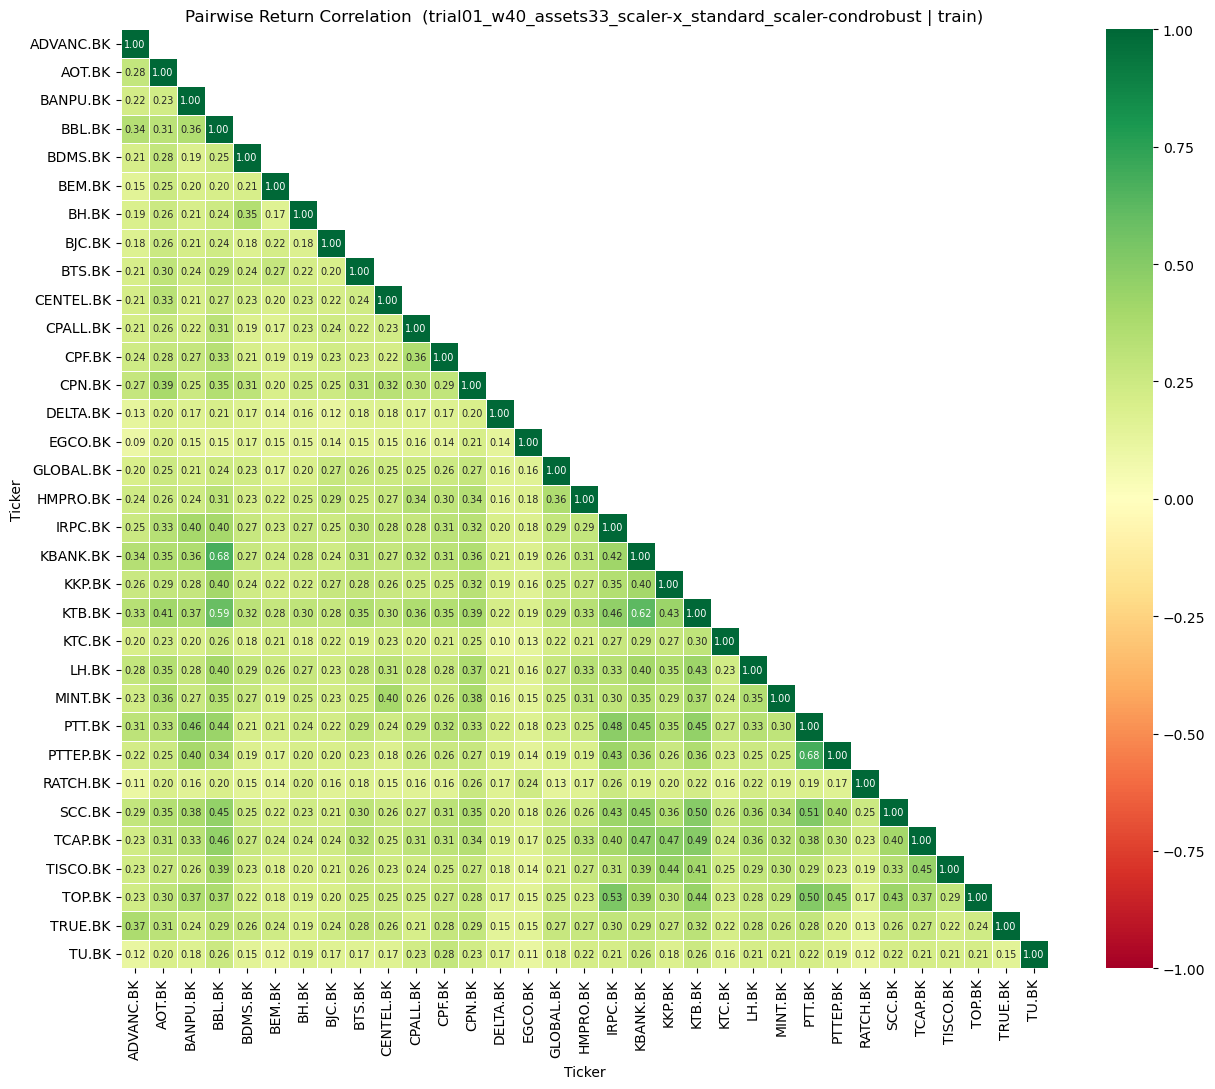

✓ trial01_w40_assets33_scaler-x_standard_scaler-condrobust_4.2_return_correlation.png

Highly correlated pairs (|r|>0.85): 0
  None found.


In [ ]:
corr = log_ret.corr()
path = atable("4.2_return_correlation.csv")
corr.to_csv(path)

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
    vmin=-1, vmax=1, center=0, linewidths=0.4, linecolor="white",
    annot_kws={"size": 7}, ax=ax,
)
ax.set_title(f"Pairwise Return Correlation  ({cfg.name} | train)", fontsize=12)
plt.tight_layout()
plt.savefig(aplot("4.2_return_correlation.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ {os.path.basename(aplot('4.2_return_correlation.png'))}")

pairs = []
for i_a, a in enumerate(corr.columns):
    for j_a, b in enumerate(corr.columns):
        if j_a <= i_a:
            continue
        r = corr.loc[a, b]
        if abs(r) > 0.85:
            pairs.append({"Asset A": a, "Asset B": b, "r": round(r, 4)})

pairs_df = (pd.DataFrame(pairs).sort_values("r", ascending=False)
            if pairs else pd.DataFrame(columns=["Asset A", "Asset B", "r"]))
path = atable("4.2_high_corr_pairs.csv")
pairs_df.to_csv(path, index=False)
print(f"\nHighly correlated pairs (|r|>0.85): {len(pairs_df)}")
print(pairs_df.to_string(index=False) if not pairs_df.empty else "  None found.")

## 4.3  Rolling Volatility Regime

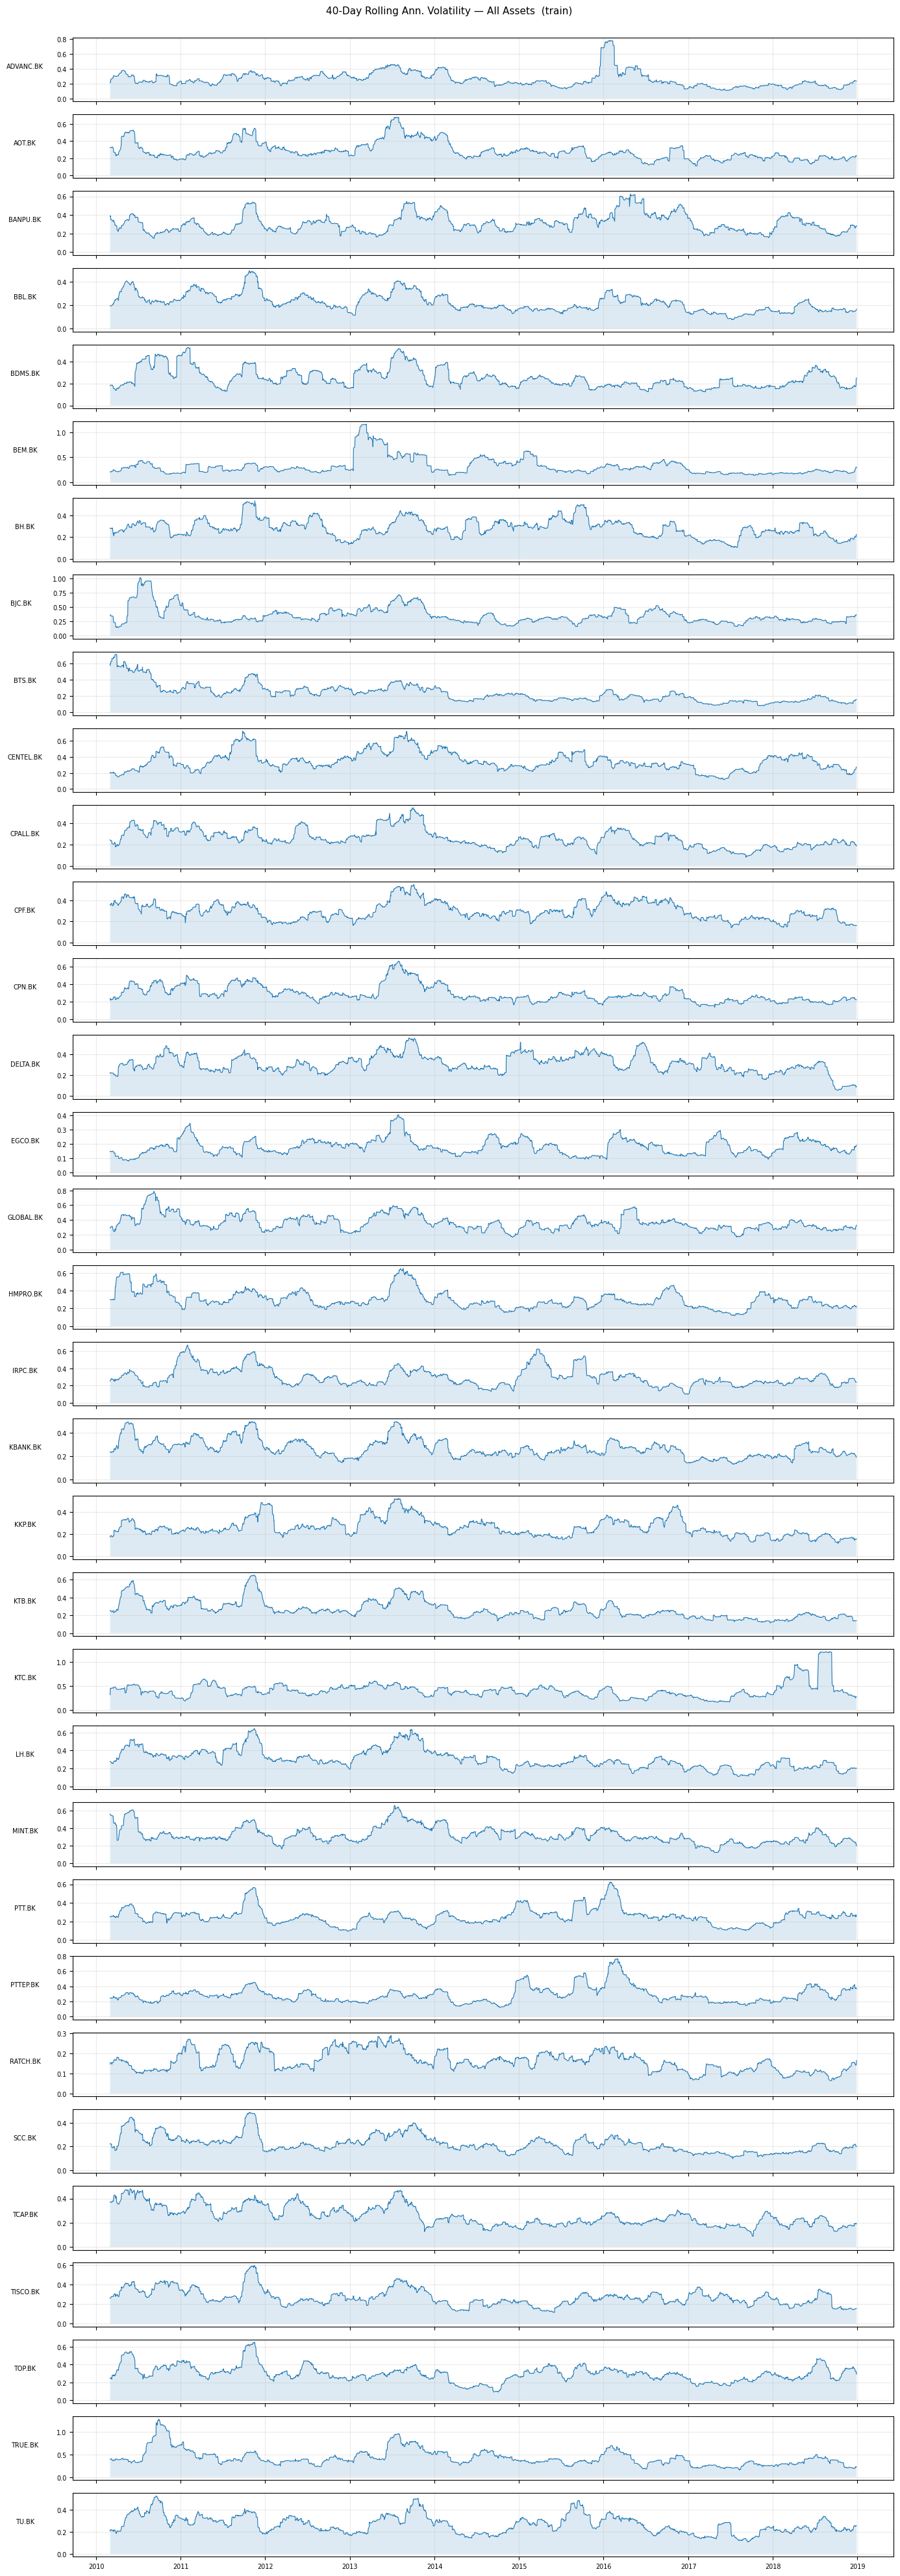

✓ trial01_w40_assets33_scaler-x_standard_scaler-condrobust_4.3_rolling_vol_per_asset.png
✓ trial01_w40_assets33_scaler-x_standard_scaler-condrobust_4.3_rolling_vol_summary.csv
           Mean_AnnVol  Max_AnnVol  Std_AnnVol
Ticker                                        
TRUE.BK         0.4259      1.2821      0.1813
KTC.BK          0.4085      1.2183      0.1646
GLOBAL.BK       0.3652      0.7856      0.1042
BJC.BK          0.3531      1.0143      0.1436
CENTEL.BK       0.3464      0.7181      0.1160
MINT.BK         0.3202      0.6576      0.0934
BEM.BK          0.3172      1.1633      0.1728
DELTA.BK        0.3090      0.5524      0.0877
BANPU.BK        0.3090      0.6259      0.0983
LH.BK           0.3043      0.6445      0.1053
HMPRO.BK        0.3014      0.6540      0.1017
CPF.BK          0.3005      0.5501      0.0837
TOP.BK          0.3005      0.6502      0.0899
IRPC.BK         0.2987      0.6705      0.1050
CPN.BK          0.2922      0.6625      0.0965
PTTEP.BK        0.2887   

In [ ]:
roll_vol = log_ret.rolling(cfg.window_size).std() * np.sqrt(252)

fig, axes = plt.subplots(n_assets, 1, figsize=(14, max(8, n_assets * 1.2)), sharex=True)
for ax, sym in zip(axes, sorted(assets)):
    ax.plot(roll_vol.index, roll_vol[sym], lw=0.8)
    ax.fill_between(roll_vol.index, roll_vol[sym], alpha=0.15)
    ax.set_ylabel(sym, fontsize=7, rotation=0, labelpad=35)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.25)

fig.suptitle(f"{cfg.window_size}-Day Rolling Ann. Volatility — All Assets  (train)", fontsize=11, y=1.001)
plt.tight_layout()
plt.savefig(aplot("4.3_rolling_vol_per_asset.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ {os.path.basename(aplot('4.3_rolling_vol_per_asset.png'))}")

vol_summary = pd.DataFrame({
    "Mean_AnnVol" : roll_vol.mean(),
    "Max_AnnVol"  : roll_vol.max(),
    "Std_AnnVol"  : roll_vol.std(),
}).round(4)
path = atable("4.3_rolling_vol_summary.csv")
vol_summary.to_csv(path)
print(f"✓ {os.path.basename(path)}")
print(vol_summary.sort_values("Mean_AnnVol", ascending=False).to_string())

## 4.4  Average Cross-Asset Volatility (Regime Indicator)

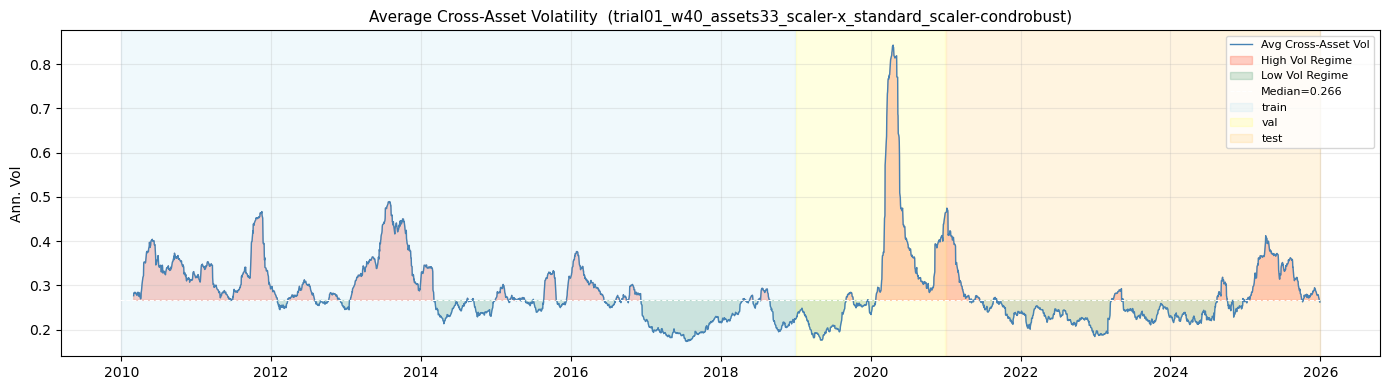

✓ trial01_w40_assets33_scaler-x_standard_scaler-condrobust_4.4_avg_vol_regime.png


In [ ]:
# ── full-period log-returns (train + val + test) ─────────────────────────────
log_ret_full = pd.concat([
    df_train_lr.xs("Close", axis=1, level=1),
    df_val_lr  .xs("Close", axis=1, level=1),
    df_test_lr .xs("Close", axis=1, level=1),
]).sort_index()

roll_vol_full = log_ret_full.rolling(cfg.window_size).std() * np.sqrt(252)
avg_vol    = roll_vol_full.mean(axis=1)
vol_median = avg_vol.median()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(avg_vol.index, avg_vol.values, lw=1, color="steelblue", label="Avg Cross-Asset Vol")
ax.fill_between(avg_vol.index, avg_vol.values, vol_median,
                where=(avg_vol.values > vol_median),  color="tomato",   alpha=0.3, label="High Vol Regime")
ax.fill_between(avg_vol.index, avg_vol.values, vol_median,
                where=(avg_vol.values <= vol_median), color="seagreen", alpha=0.2, label="Low Vol Regime")
ax.axhline(vol_median, color="white", lw=0.8, ls="--", label=f"Median={vol_median:.3f}")

for period, color, label in [
    (cfg.train_period, "skyblue", "train"),
    (cfg.val_period,   "yellow",  "val"),
    (cfg.test_period,  "orange",  "test"),
]:
    ax.axvspan(pd.Timestamp(period[0]), pd.Timestamp(period[1]),
               alpha=0.12, color=color, label=label)

ax.set_title(f"Average Cross-Asset Volatility  ({cfg.name})", fontsize=11)
ax.set_ylabel("Ann. Vol")
ax.legend(fontsize=8, loc="upper right")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(aplot("4.4_avg_vol_regime.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ {os.path.basename(aplot('4.4_avg_vol_regime.png'))}")

## 4.4b  Window-Size Sensitivity — Pairwise Comparison (20v40, 40v60, 20v60)

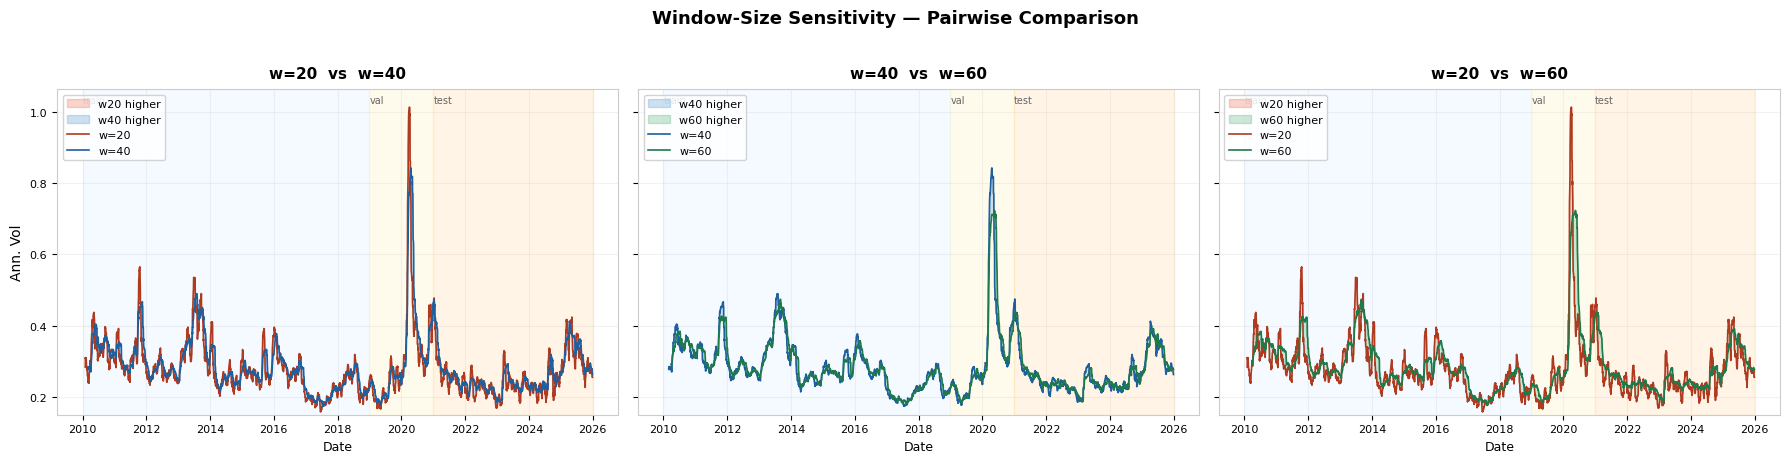

✓ trial01_w40_assets33_scaler-x_standard_scaler-condrobust_4.4b_window_sensitivity.png


In [ ]:
COMPARE_WINDOWS = [20, 40, 60]
PAIRS  = [(20, 40), (40, 60), (20, 60)]
COLORS = {20: ("#e8735a", "#b03a20"), 40: ("#5b9bd5", "#1e5f9e"), 60: ("#56b37f", "#1e7a4a")}

vol_series = {}
for w in COMPARE_WINDOWS:
    rv = log_ret_full.rolling(w).std() * np.sqrt(252)   # ← log_ret_full แทน log_ret
    vol_series[w] = rv.mean(axis=1)
vol_df = pd.DataFrame(vol_series)

y_min = vol_df.min().min() * 0.95
y_max = vol_df.max().max() * 1.05

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True)
fig.patch.set_facecolor("white")

for ax, (wa, wb) in zip(axes, PAIRS):
    sa, sb     = vol_df[wa], vol_df[wb]
    fc_a, lc_a = COLORS[wa]
    fc_b, lc_b = COLORS[wb]

    ax.fill_between(sa.index, sa, sb, where=(sa >= sb), color=fc_a, alpha=0.30, label=f"w{wa} higher")
    ax.fill_between(sa.index, sa, sb, where=(sa <  sb), color=fc_b, alpha=0.30, label=f"w{wb} higher")
    ax.plot(sa.index, sa, color=lc_a, lw=1.2, label=f"w={wa}")
    ax.plot(sb.index, sb, color=lc_b, lw=1.2, label=f"w={wb}")

    for period, shade, tag in [
        (cfg.train_period, "#aaddff", "train"),   # ← เพิ่ม train
        (cfg.val_period,   "#ffe066", "val"),
        (cfg.test_period,  "#ffaa33", "test"),
    ]:
        ax.axvspan(pd.Timestamp(period[0]), pd.Timestamp(period[1]), alpha=0.12, color=shade, zorder=0)
        ax.text(pd.Timestamp(period[0]), y_max * 0.985, tag, fontsize=7, color="#666", va="top")

    ax.set_ylim(y_min, y_max)
    ax.set_title(f"w={wa}  vs  w={wb}", fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel("Date", fontsize=9)
    ax.legend(fontsize=8, loc="upper left", framealpha=0.85)
    ax.grid(alpha=0.25, color="#cccccc")
    ax.set_facecolor("white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#cccccc")
    ax.tick_params(labelsize=8)

axes[0].set_ylabel("Ann. Vol", fontsize=10)
fig.suptitle("Window-Size Sensitivity — Pairwise Comparison", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(aplot("4.4b_window_sensitivity.png"), dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"✓ {os.path.basename(aplot('4.4b_window_sensitivity.png'))}")

## 4.5  Conditioning Feature Distribution

✓ trial01_w40_assets33_scaler-x_standard_scaler-condrobust_4.5_feature_stats.csv
                                      mean       std        min        max      skew       kurt
ADOSC_3_10_minmax                 0.494096  0.369025   0.000000   1.000000  0.023496  -1.484026
ADX_14_minmax                     0.456696  0.430204   0.000000   1.000000  0.174527  -1.738748
ATR_14_minmax                     0.460626  0.392943   0.000000   1.000000  0.131133  -1.602745
BBANDS_lowerband_distance_close   0.059621  0.054590  -0.218267   0.593178  1.639274   4.366373
BBANDS_middleband_distance_close  0.004071  0.044215  -0.469835   0.352410 -0.510537   4.240155
BBANDS_upperband_distance_close  -0.051480  0.057478  -1.003576   0.117423 -2.890285  15.702657
CCI_14_minmax                     0.492253  0.340144   0.000000   1.000000  0.032957  -1.292983
EMA_10_distance_close             0.001900  0.025766  -0.408526   0.241150 -0.490503   5.718087
EMA_200_distance_close            0.051361  0.116532  -

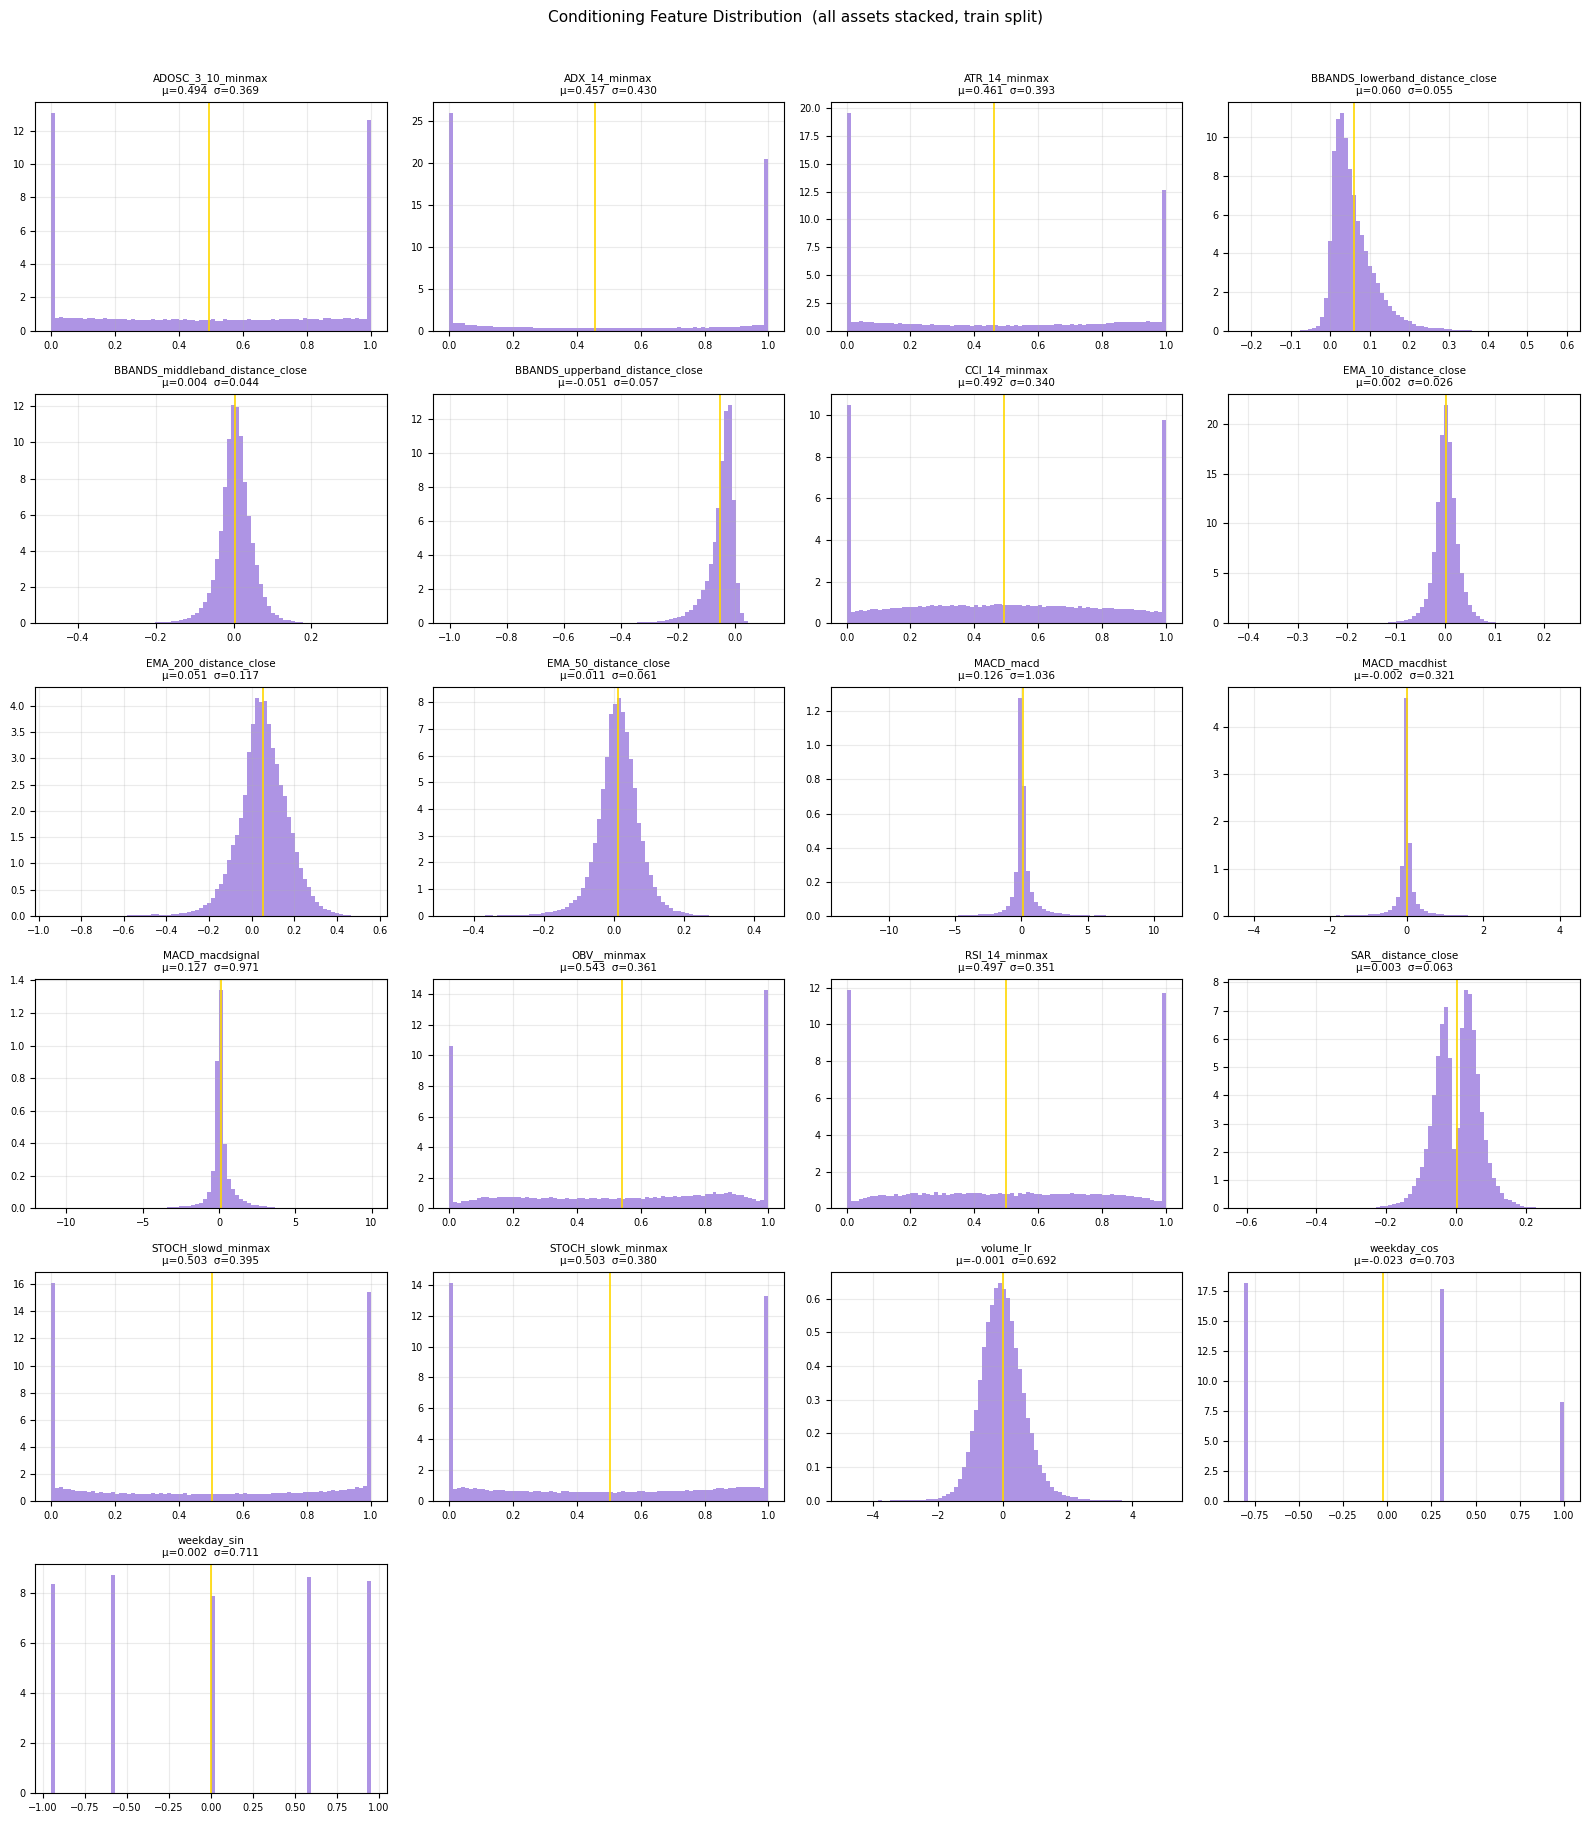

✓ trial01_w40_assets33_scaler-x_standard_scaler-condrobust_4.5_feature_distributions.png


In [ ]:
feat_cols_check = df_train_cond.xs(assets[0], axis=1, level=0).columns.tolist()

feat_stacked = np.concatenate(
    [df_train_cond.xs(sym, axis=1, level=0).values for sym in assets], axis=0
)
feat_stacked_df = pd.DataFrame(feat_stacked, columns=feat_cols_check)

feat_stats = feat_stacked_df.describe().T
feat_stats["skew"] = feat_stacked_df.skew()
feat_stats["kurt"] = feat_stacked_df.kurt()
feat_stats = feat_stats.round(6)
path = atable("4.5_feature_stats.csv")
feat_stats.to_csv(path)
print(f"✓ {os.path.basename(path)}")
print(feat_stats[["mean", "std", "min", "max", "skew", "kurt"]].to_string())

n_feats  = len(feat_cols_check)
ncols_f  = 4
nrows_f  = math.ceil(n_feats / ncols_f)

fig, axes = plt.subplots(nrows_f, ncols_f, figsize=(ncols_f * 4, nrows_f * 3))
axes = axes.flatten()

for i, col in enumerate(feat_cols_check):
    ax   = axes[i]
    vals = feat_stacked_df[col].dropna()
    ax.hist(vals, bins=80, color="mediumpurple", alpha=0.75, density=True, edgecolor="none")
    ax.axvline(vals.mean(), color="gold", lw=1.2)
    ax.set_title(f"{col}\nμ={vals.mean():.3f}  σ={vals.std():.3f}", fontsize=7.5)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.25)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Conditioning Feature Distribution  (all assets stacked, train split)", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(aplot("4.5_feature_distributions.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ {os.path.basename(aplot('4.5_feature_distributions.png'))}")

## 4.6  Feature × Feature Correlation

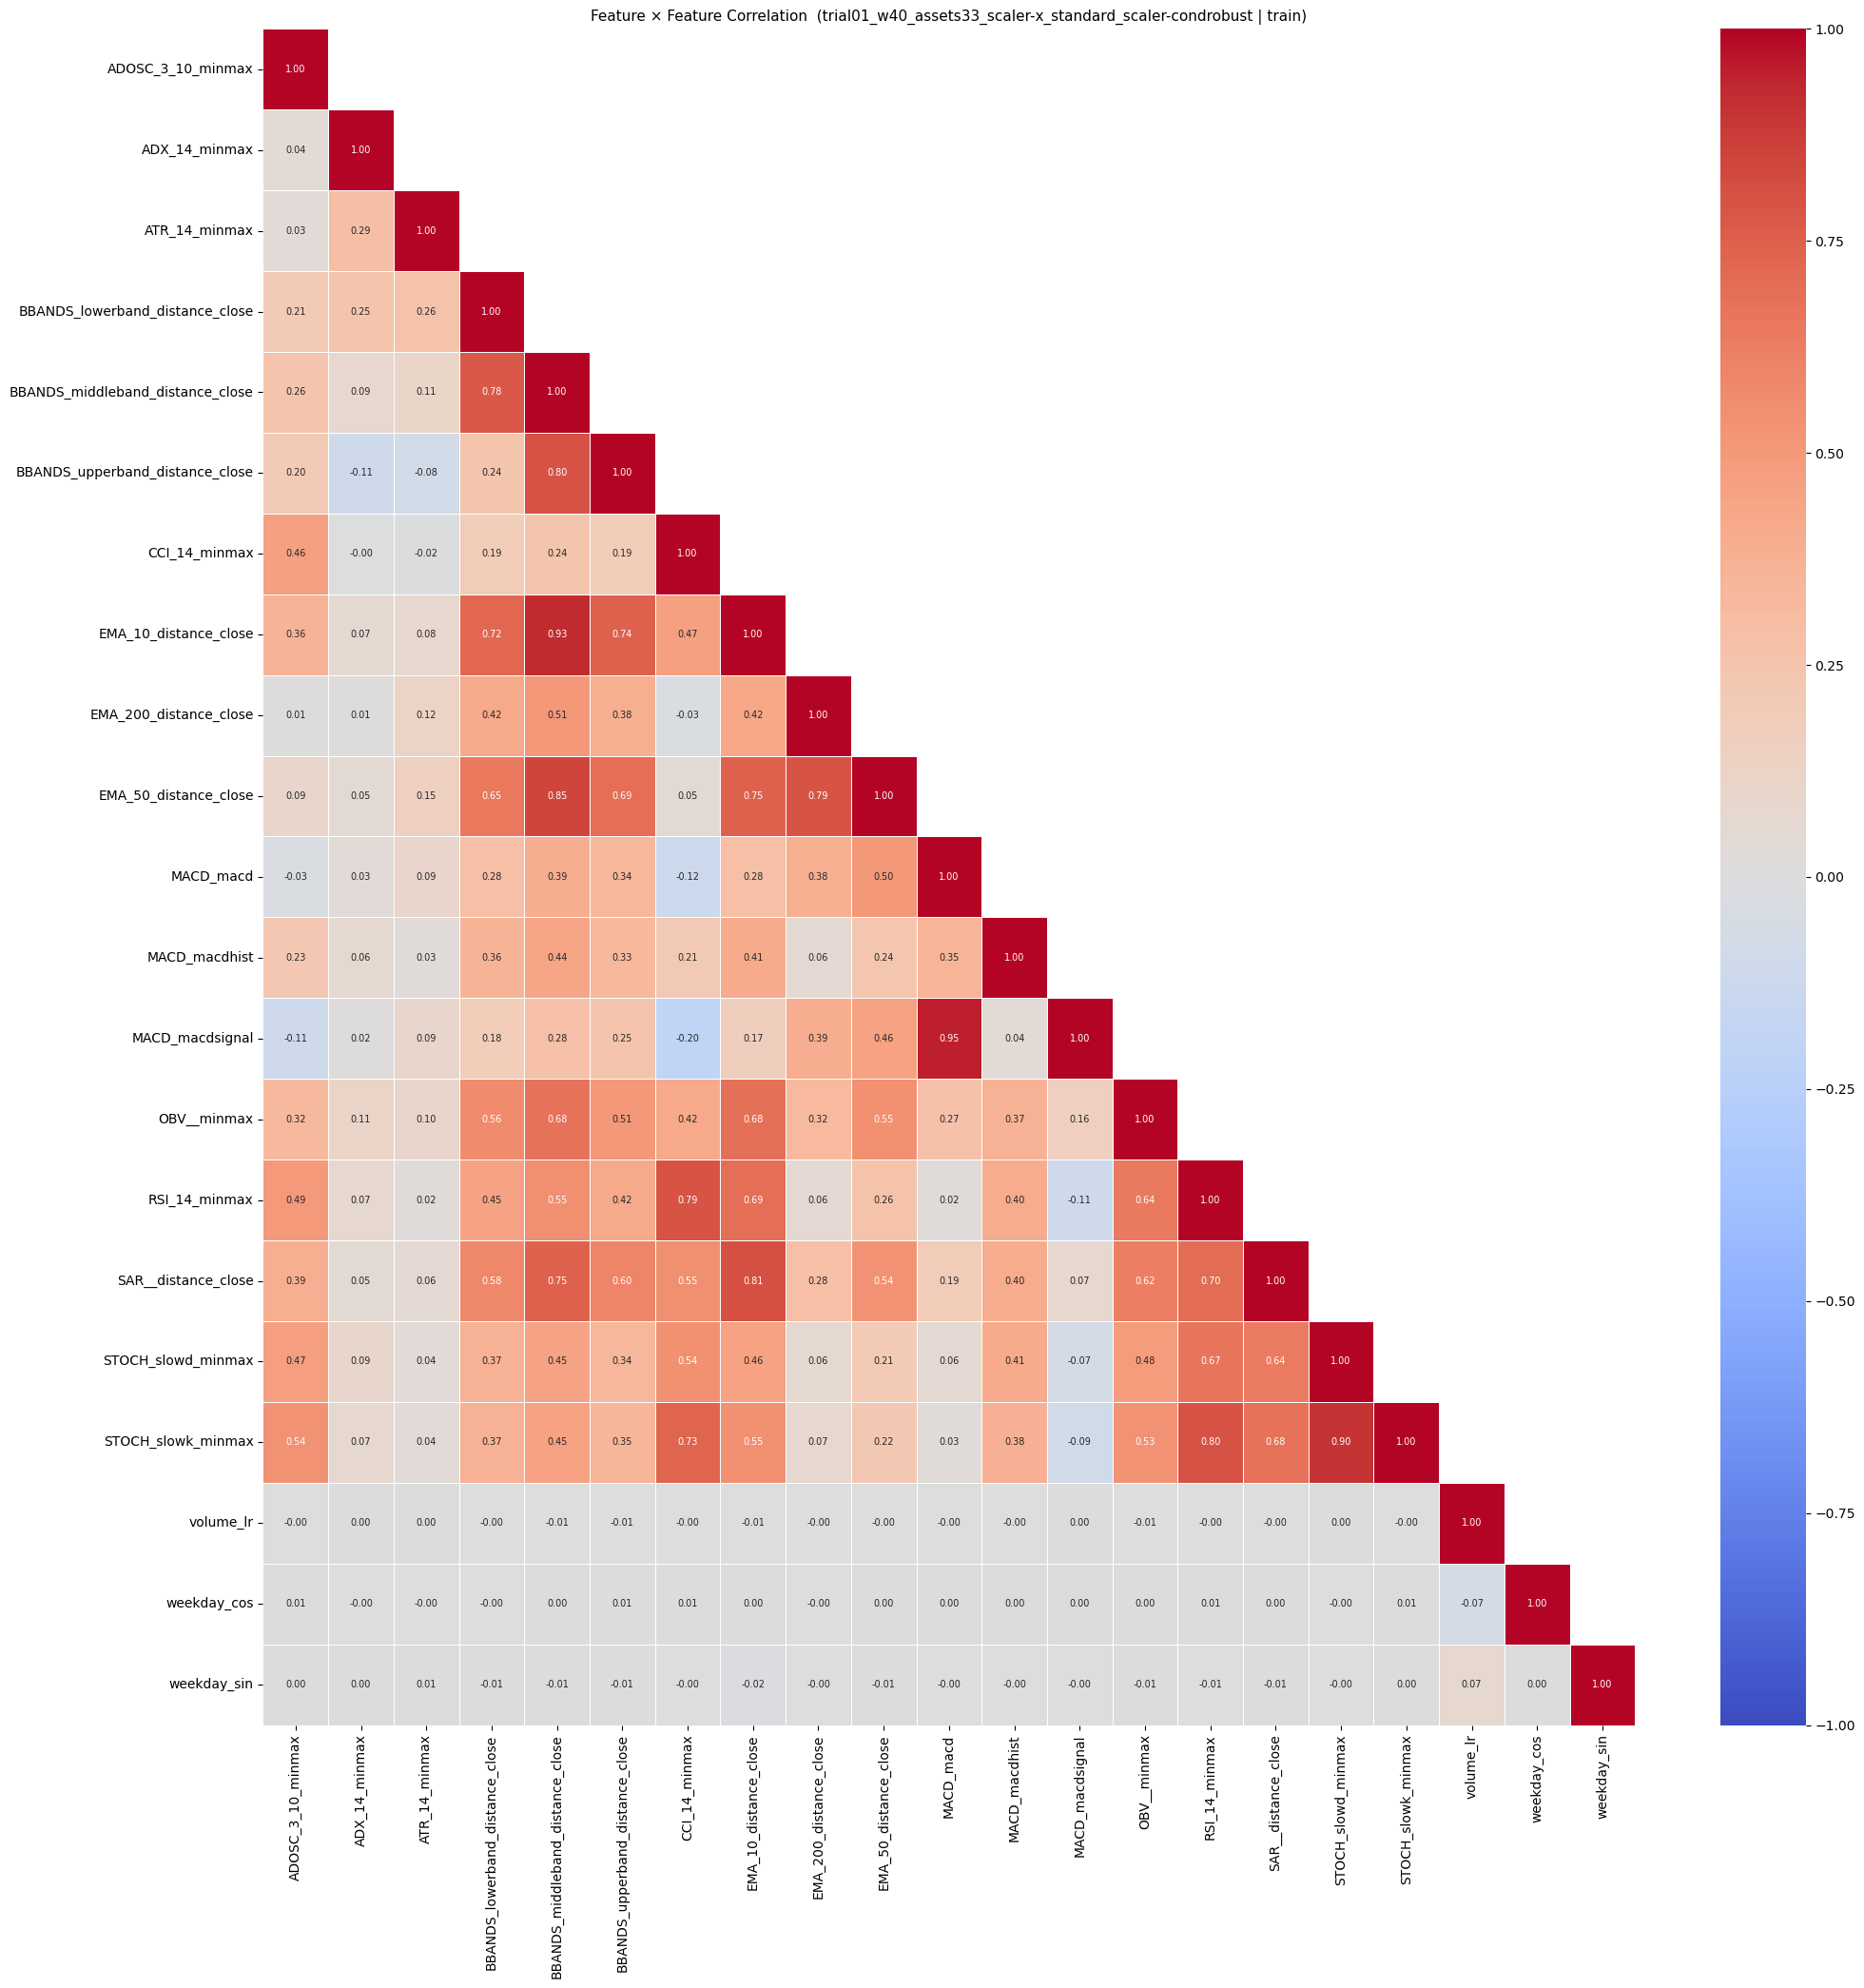

✓ trial01_w40_assets33_scaler-x_standard_scaler-condrobust_4.6_feature_correlation.png


In [ ]:
feat_corr = feat_stacked_df.corr()
path = atable("4.6_feature_correlation.csv")
feat_corr.to_csv(path)

mask_f = np.triu(np.ones_like(feat_corr, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(max(10, n_feats), max(8, n_feats)))
sns.heatmap(
    feat_corr, mask=mask_f, annot=True, fmt=".2f", cmap="coolwarm",
    vmin=-1, vmax=1, center=0, linewidths=0.4, linecolor="white",
    annot_kws={"size": 7}, ax=ax,
)
ax.set_title(f"Feature × Feature Correlation  ({cfg.name} | train)", fontsize=11)
plt.tight_layout()
plt.savefig(aplot("4.6_feature_correlation.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ {os.path.basename(aplot('4.6_feature_correlation.png'))}")

## 4.7  Feature vs Next-Day Return (Predictive Correlation)

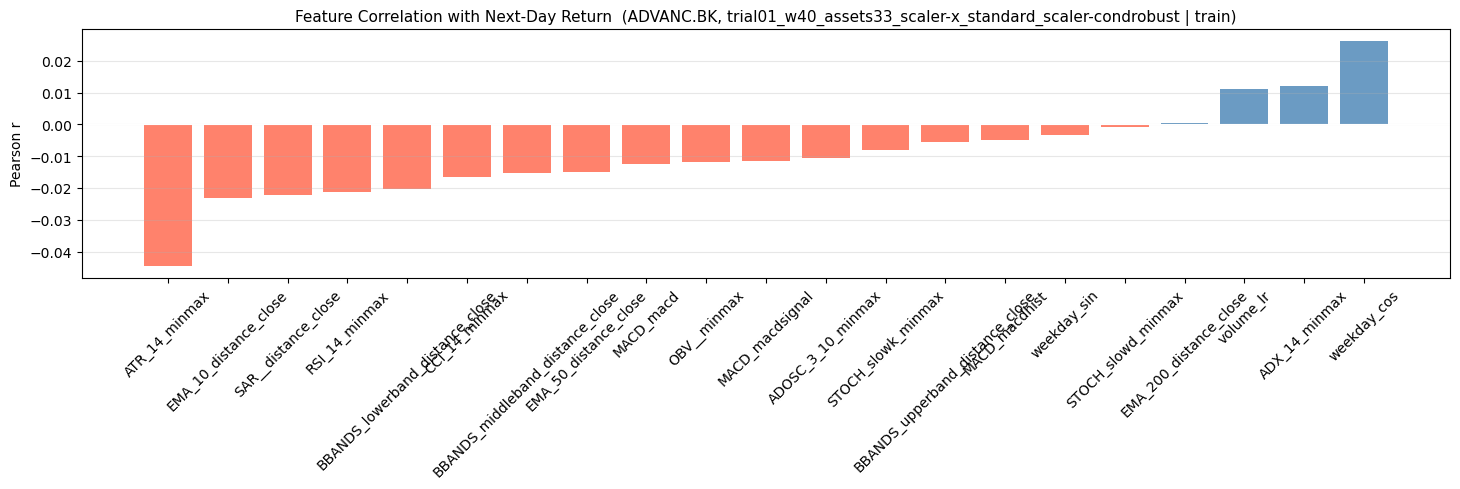

✓ trial01_w40_assets33_scaler-x_standard_scaler-condrobust_4.7_feature_corr_nextday_ADVANC.BK.png


In [ ]:
rep_sym  = "ADVANC.BK" if "ADVANC.BK" in assets else assets[0]
feat_rep = df_train_cond.xs(rep_sym, axis=1, level=0).copy()
ret_1d   = log_ret[[rep_sym]].rename(columns={rep_sym: "ret_1d"})
merged   = feat_rep.join(ret_1d.shift(-1)).dropna()
pred_corr = merged.corr()["ret_1d"].drop("ret_1d").sort_values()

pred_corr_df = pred_corr.reset_index()
pred_corr_df.columns = ["feature", "pearson_r"]
path = atable(f"4.7_predictive_corr_{rep_sym}.csv")
pred_corr_df.to_csv(path, index=False)

fig, ax = plt.subplots(figsize=(max(10, len(pred_corr) * 0.7), 5))
colors = ["tomato" if v < 0 else "steelblue" for v in pred_corr.values]
ax.bar(pred_corr.index, pred_corr.values, color=colors, alpha=0.8, edgecolor="none")
ax.axhline(0, color="white", lw=0.8)
ax.set_title(f"Feature Correlation with Next-Day Return  ({rep_sym}, {cfg.name} | train)", fontsize=11)
ax.set_ylabel("Pearson r")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(aplot(f"4.7_feature_corr_nextday_{rep_sym}.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ {os.path.basename(aplot(f'4.7_feature_corr_nextday_{rep_sym}.png'))}")

## 4.8  PCA — Feature Importance & Market Mode

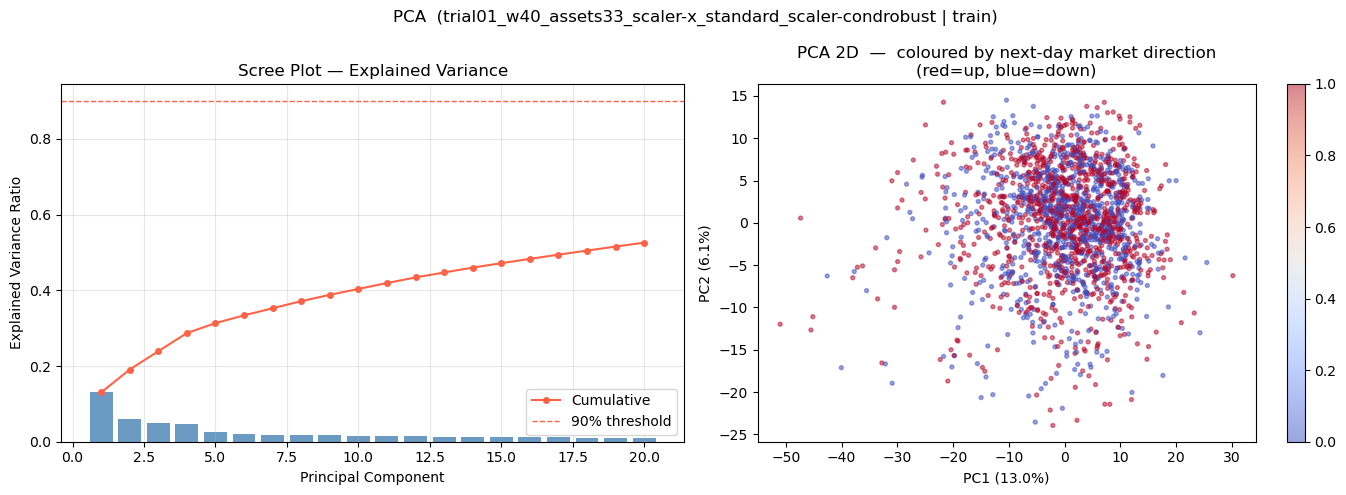

✓ trial01_w40_assets33_scaler-x_standard_scaler-condrobust_4.8_pca.png

  Components for 90% variance : 136  (out of 693)
  PC1 explains               : 13.0%
  Top PC1 feature            : KTB.BK_BBANDS_middleband_distance_close

  Top-10 loadings on PC1:
KTB.BK_BBANDS_middleband_distance_close      0.080998
KTB.BK_EMA_10_distance_close                 0.077136
BBL.BK_BBANDS_middleband_distance_close      0.076064
KBANK.BK_BBANDS_middleband_distance_close    0.075979
TCAP.BK_BBANDS_middleband_distance_close     0.074392
CPN.BK_BBANDS_middleband_distance_close      0.073316
KBANK.BK_EMA_50_distance_close               0.072180
TCAP.BK_EMA_10_distance_close                0.071856
LH.BK_BBANDS_middleband_distance_close       0.070975
BBL.BK_EMA_10_distance_close                 0.070768


In [ ]:
frames = []
for s in sorted(assets):
    fd = df_train_cond.xs(s, axis=1, level=0).copy().dropna()
    fd.columns = [f"{s}_{c}" for c in fd.columns]
    frames.append(fd)

X_all = pd.concat(frames, axis=1).dropna()

# label: next-day avg market return direction
y_all = (log_ret.reindex(X_all.index).mean(axis=1).shift(-1) > 0).astype(int).reindex(X_all.index).dropna()
X_all = X_all.reindex(y_all.index)

sk_scaler = StandardScaler()
X_sc      = sk_scaler.fit_transform(X_all)

pca_full = PCA().fit(X_sc)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_)
n90      = int(np.argmax(cum_var >= 0.90)) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, 21), pca_full.explained_variance_ratio_[:20], color="steelblue", alpha=0.8)
axes[0].plot(range(1, 21), cum_var[:20], color="tomato", marker="o", ms=4, label="Cumulative")
axes[0].axhline(0.90, color="tomato", ls="--", lw=1, label="90% threshold")
axes[0].set_title("Scree Plot — Explained Variance")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].legend()
axes[0].grid(alpha=0.3)

pca2   = PCA(n_components=2).fit_transform(X_sc)
sc_pca = axes[1].scatter(pca2[:, 0], pca2[:, 1], c=y_all.values, cmap="coolwarm", alpha=0.5, s=8)
axes[1].set_title("PCA 2D  —  coloured by next-day market direction\n(red=up, blue=down)")
axes[1].set_xlabel(f"PC1 ({pca_full.explained_variance_ratio_[0]:.1%})")
axes[1].set_ylabel(f"PC2 ({pca_full.explained_variance_ratio_[1]:.1%})")
plt.colorbar(sc_pca, ax=axes[1])
fig.suptitle(f"PCA  ({cfg.name} | train)", fontsize=12)
plt.tight_layout()
plt.savefig(aplot("4.8_pca.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ {os.path.basename(aplot('4.8_pca.png'))}")

loadings = pd.Series(np.abs(pca_full.components_[0]), index=X_all.columns).sort_values(ascending=False)
loadings.head(20).rename("loading").to_frame().to_csv(atable("4.8_pca_loadings.csv"))
pd.DataFrame([{
    "n_components_90pct" : n90,
    "total_features"     : X_all.shape[1],
    "pc1_explained_var"  : pca_full.explained_variance_ratio_[0],
    "top_feature_pc1"    : loadings.index[0],
}]).to_csv(atable("4.8_pca_summary.csv"), index=False)

print(f"\n  Components for 90% variance : {n90}  (out of {X_all.shape[1]})")
print(f"  PC1 explains               : {pca_full.explained_variance_ratio_[0]:.1%}")
print(f"  Top PC1 feature            : {loadings.index[0]}")
print(f"\n  Top-10 loadings on PC1:")
print(loadings.head(10).to_string())

## 4.9  t-SNE — Market Regime Clustering

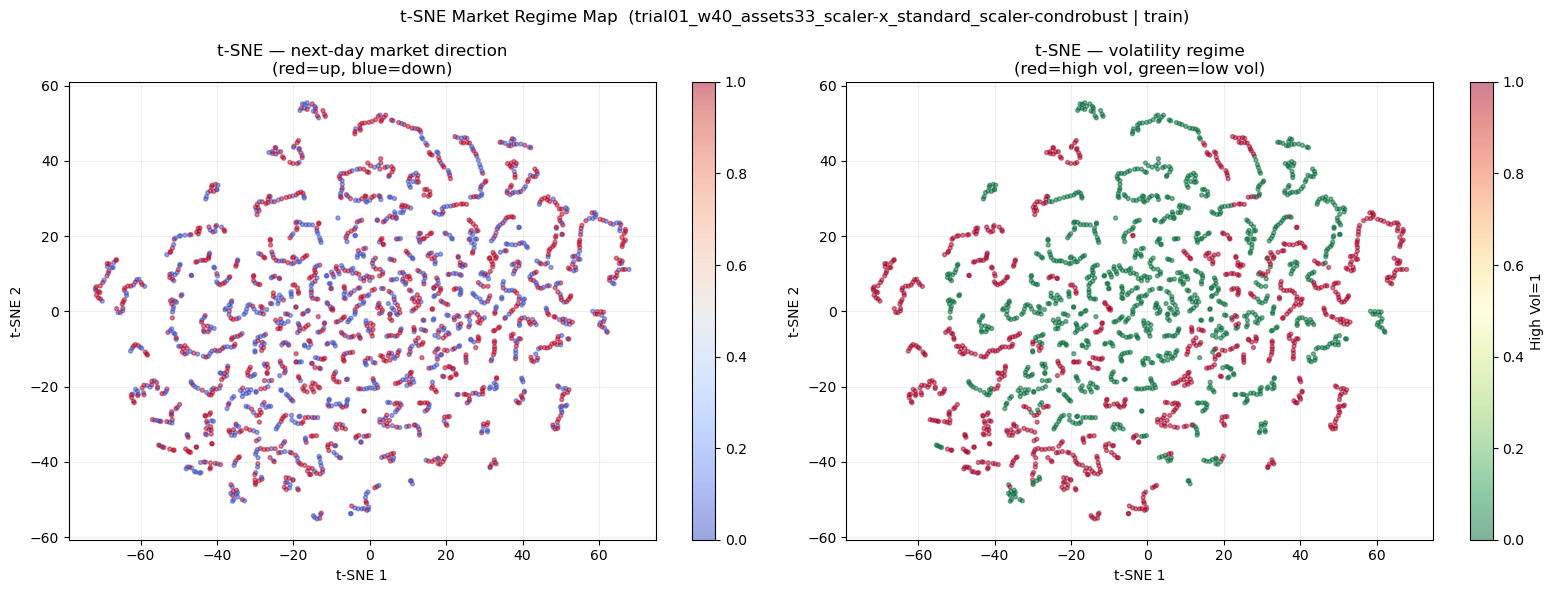

✓ trial01_w40_assets33_scaler-x_standard_scaler-condrobust_4.9_tsne.png


In [ ]:
roll_vol_aligned = (log_ret.rolling(cfg.window_size).std() * np.sqrt(252)).mean(axis=1)
vol_regime       = (roll_vol_aligned > roll_vol_aligned.median()).astype(int).reindex(y_all.index)

X_pca_n90 = PCA(n_components=min(n90, 50)).fit_transform(X_sc)

tsne   = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=cfg.random_seed)
X_tsne = tsne.fit_transform(X_pca_n90)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc1 = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_all.values,
                      cmap="coolwarm", alpha=0.5, s=8)
axes[0].set_title("t-SNE — next-day market direction\n(red=up, blue=down)")
plt.colorbar(sc1, ax=axes[0])

sc2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=vol_regime.reindex(y_all.index).values,
                      cmap="RdYlGn_r", alpha=0.5, s=8)
axes[1].set_title("t-SNE — volatility regime\n(red=high vol, green=low vol)")
plt.colorbar(sc2, ax=axes[1], label="High Vol=1")

for ax in axes:
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.grid(alpha=0.2)

fig.suptitle(f"t-SNE Market Regime Map  ({cfg.name} | train)", fontsize=12)
plt.tight_layout()
plt.savefig(aplot("4.9_tsne.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ {os.path.basename(aplot('4.9_tsne.png'))}")

## 4.10  UMAP — Global Structure

/home/narodom.y@FUSION.LAB/.conda/envs/tsgenai/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


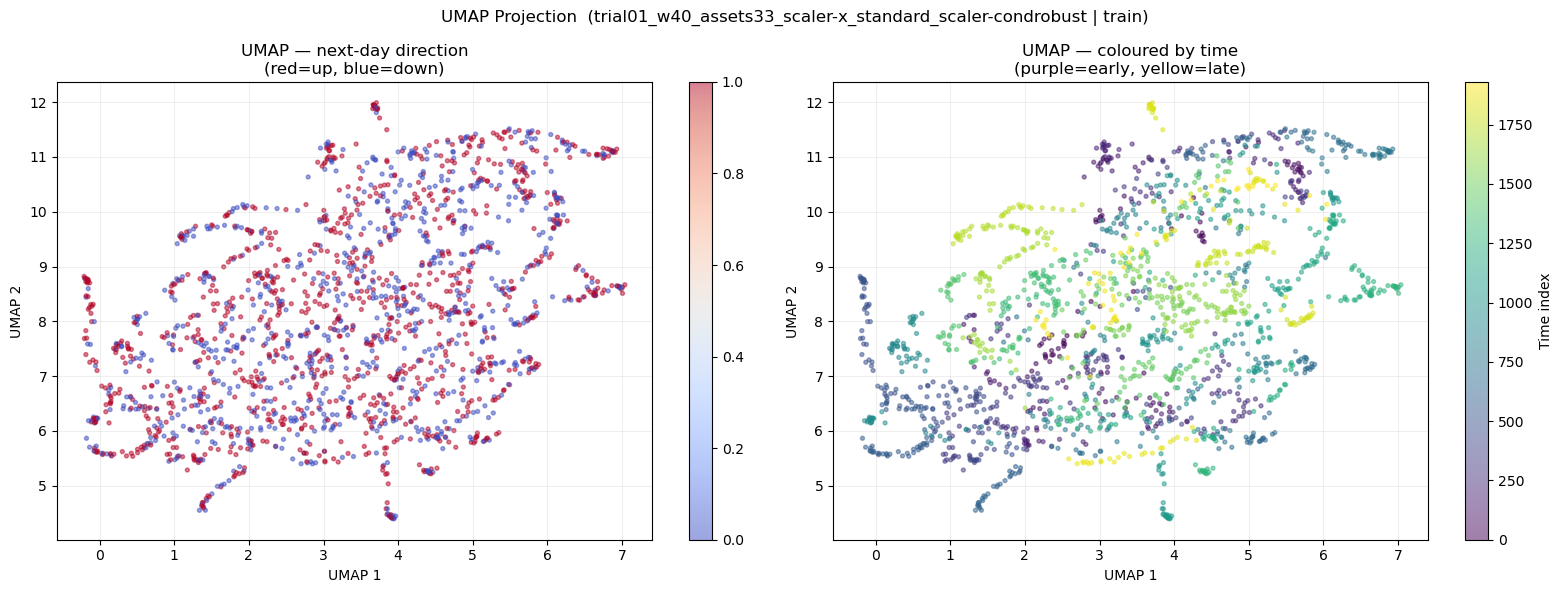

✓ trial01_w40_assets33_scaler-x_standard_scaler-condrobust_4.10_umap.png


In [ ]:
reducer = umap_lib.UMAP(n_neighbors=15, min_dist=0.1, n_components=2,
                         random_state=cfg.random_seed)
X_umap  = reducer.fit_transform(X_pca_n90)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc1 = axes[0].scatter(X_umap[:, 0], X_umap[:, 1], c=y_all.values,
                      cmap="coolwarm", alpha=0.5, s=8)
axes[0].set_title("UMAP — next-day direction\n(red=up, blue=down)")
plt.colorbar(sc1, ax=axes[0])

sc2 = axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=np.arange(len(X_umap)),
                      cmap="viridis", alpha=0.5, s=8)
axes[1].set_title("UMAP — coloured by time\n(purple=early, yellow=late)")
plt.colorbar(sc2, ax=axes[1], label="Time index")

for ax in axes:
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.grid(alpha=0.2)

fig.suptitle(f"UMAP Projection  ({cfg.name} | train)", fontsize=12)
plt.tight_layout()
plt.savefig(aplot("4.10_umap.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ {os.path.basename(aplot('4.10_umap.png'))}")

## 4.11  Raw Data Export

In [ ]:
# ── Close log-returns per split ───────────────────────────────────────────
for split_name, df_lr in [
    ("train", df_train_lr),
    ("val",   df_val_lr),
    ("test",  df_test_lr),
]:
    close_lr = df_lr.xs("Close", axis=1, level=1)
    path = atable(f"4.11_log_returns_{split_name}.csv")
    close_lr.to_csv(path)
    print(f"✓ {os.path.basename(path)}  shape={close_lr.shape}")

# ── Conditioning features per split ──────────────────────────────────────
for split_name, df_cond_s in [
    ("train", df_train_cond),
    ("val",   df_val_cond),
    ("test",  df_test_cond),
]:
    df_flat = df_cond_s.copy()
    df_flat.columns = [f"{sym}_{feat}" for sym, feat in df_flat.columns]
    path = atable(f"4.11_cond_features_{split_name}.csv")
    df_flat.to_csv(path)
    print(f"✓ {os.path.basename(path)}  shape={df_flat.shape}")

✓ trial01_w40_assets33_scaler-x_standard_scaler-condrobust_4.11_log_returns_train.csv  shape=(2197, 33)
✓ trial01_w40_assets33_scaler-x_standard_scaler-condrobust_4.11_log_returns_val.csv  shape=(486, 33)
✓ trial01_w40_assets33_scaler-x_standard_scaler-condrobust_4.11_log_returns_test.csv  shape=(1209, 33)
✓ trial01_w40_assets33_scaler-x_standard_scaler-condrobust_4.11_cond_features_train.csv  shape=(1931, 693)
✓ trial01_w40_assets33_scaler-x_standard_scaler-condrobust_4.11_cond_features_val.csv  shape=(248, 693)
✓ trial01_w40_assets33_scaler-x_standard_scaler-condrobust_4.11_cond_features_test.csv  shape=(834, 693)


## 4.12  Summary

In [ ]:
print("=" * 65)
print(f"  SECTION 4 — DATA ANALYSIS SUMMARY  [{cfg.name}]")
print("=" * 65)

print(f"\n  Assets  : {len(assets)}  →  {sorted(assets)}")
print(f"  Train   : {len(log_ret)} days")

print(f"\n[Return Stats]")
print(f"  Most volatile  : {stats_df['Std'].idxmax():<20}  σ={stats_df['Std'].max():.4f}")
print(f"  Least volatile : {stats_df['Std'].idxmin():<20}  σ={stats_df['Std'].min():.4f}")
print(f"  Best Sharpe    : {stats_df['Sharpe'].idxmax():<20}  SR={stats_df['Sharpe'].max():.3f}")

print(f"\n[Correlation]")
print(f"  High-corr pairs (|r|>0.85) : {len(pairs_df)}")

print(f"\n[Conditioning Features]  {len(feat_cols_check)} features/asset")
for col in feat_cols_check:
    mu  = feat_stats.loc[col, "mean"]
    std = feat_stats.loc[col, "std"]
    sk  = feat_stats.loc[col, "skew"]
    print(f"  {col:<45}  μ={mu:+.4f}  σ={std:.4f}  skew={sk:+.3f}")

print(f"\n[PCA]")
print(f"  PC1 explains    : {pca_full.explained_variance_ratio_[0]:.1%}")
print(f"  Components@90%  : {n90}  (out of {X_all.shape[1]})")
print(f"  Top PC1 feature : {loadings.index[0]}")

print(f"\n[Output]")
print(f"  Plots  → {cfg.analysis_figure_dir}")
print(f"  Tables → {cfg.analysis_table_dir}")
print(f"\n✓ Section 4 complete")

  SECTION 4 — DATA ANALYSIS SUMMARY  [trial01_w40_assets33_scaler-x_standard_scaler-condrobust]

  Assets  : 33  →  ['ADVANC.BK', 'AOT.BK', 'BANPU.BK', 'BBL.BK', 'BDMS.BK', 'BEM.BK', 'BH.BK', 'BJC.BK', 'BTS.BK', 'CENTEL.BK', 'CPALL.BK', 'CPF.BK', 'CPN.BK', 'DELTA.BK', 'EGCO.BK', 'GLOBAL.BK', 'HMPRO.BK', 'IRPC.BK', 'KBANK.BK', 'KKP.BK', 'KTB.BK', 'KTC.BK', 'LH.BK', 'MINT.BK', 'PTT.BK', 'PTTEP.BK', 'RATCH.BK', 'SCC.BK', 'TCAP.BK', 'TISCO.BK', 'TOP.BK', 'TRUE.BK', 'TU.BK']
  Train   : 2197 days

[Return Stats]
  Most volatile  : TRUE.BK               σ=0.0291
  Least volatile : RATCH.BK              σ=0.0107
  Best Sharpe    : AOT.BK                SR=1.130

[Correlation]
  High-corr pairs (|r|>0.85) : 0

[Conditioning Features]  21 features/asset
  ADOSC_3_10_minmax                              μ=+0.4941  σ=0.3690  skew=+0.023
  ADX_14_minmax                                  μ=+0.4567  σ=0.4302  skew=+0.175
  ATR_14_minmax                                  μ=+0.4606  σ=0.3929  skew=+0.131

# 5. Data Sequences
สร้าง lagged feature DataFrame จาก df_train_lr_aligned

Notation (ตามที่กำหนด):
  * d=0  → ค่าปัจจุบัน  (t)
  * d=1  → ย้อนหลัง 1 วัน (t-1)
  * d=k  → ย้อนหลัง k วัน (t-k)

Output columns (MultiIndex level 2):
  (feature, asset, "d0"), (feature, asset, "d1"), ..., (feature, asset, "d{W-1}")
หรือถ้าต้องการแบบ flat 2-level:
  (feature_d0, asset), (feature_d1, asset), ...

In [ ]:
def create_lagged_df(df: pd.DataFrame, lag: int):
    lag_frames = []
    pad = len(str(lag - 1))
    for d in range(lag):
        shifted = df.shift(d + 1)
        shifted.columns = pd.MultiIndex.from_tuples(
            [(feat, asset, f"d{d:0{pad}d}") for feat, asset in df.columns],
            names=[*df.columns.names, "Lag Sequence"],
        )
        lag_frames.append(shifted)

    df_lagged = pd.concat(lag_frames, axis=1).sort_index(axis=1)
    df_lagged = df_lagged.iloc[lag:]
    return df_lagged

# ── train ──────────────────────────────────────────────────────────────────
df_train_seq            = create_lagged_df(df_train_lr_aligned, lag=cfg.window_size)
df_train_lr_aligned     = df_train_lr_aligned.reindex(df_train_seq.index)
df_train_cond_aligned   = df_train_cond_aligned.reindex(df_train_seq.index)
df_train_seq_aligned    = df_train_seq

# ── val ────────────────────────────────────────────────────────────────────
df_val_seq              = create_lagged_df(df_val_lr_aligned,   lag=cfg.window_size)
df_val_lr_aligned       = df_val_lr_aligned.reindex(df_val_seq.index)
df_val_cond_aligned     = df_val_cond_aligned.reindex(df_val_seq.index)
df_val_seq_aligned      = df_val_seq

# ── test ───────────────────────────────────────────────────────────────────
df_test_seq             = create_lagged_df(df_test_lr_aligned,  lag=cfg.window_size)
df_test_lr_aligned      = df_test_lr_aligned.reindex(df_test_seq.index)
df_test_cond_aligned    = df_test_cond_aligned.reindex(df_test_seq.index)
df_test_seq_aligned     = df_test_seq

# ── Train ──────────────────────────────────────────────────────────────────
print("── Train Lagged Sequence DataFrame ───────────────────────────────────")
print(f"  Shape            : {df_train_seq.shape}")
print(f"  Index            : {df_train_seq.index[0].date()} → {df_train_seq.index[-1].date()}")
print(f"  Column levels    : {df_train_seq.columns.names}\n")

# ── Val ────────────────────────────────────────────────────────────────────
print("── Val Lagged Sequence DataFrame ─────────────────────────────────────")
print(f"  Shape            : {df_val_seq.shape}")
print(f"  Index            : {df_val_seq.index[0].date()} → {df_val_seq.index[-1].date()}")
print(f"  Column levels    : {df_val_seq.columns.names}\n")

# ── Test ───────────────────────────────────────────────────────────────────
print("── Test Lagged Sequence DataFrame ────────────────────────────────────")
print(f"  Shape            : {df_test_seq.shape}")
print(f"  Index            : {df_test_seq.index[0].date()} → {df_test_seq.index[-1].date()}")
print(f"  Column levels    : {df_test_seq.columns.names}\n")

for name, lr, cond, seq in [
    ("train", df_train_lr_aligned, df_train_cond_aligned, df_train_seq_aligned),
    ("val",   df_val_lr_aligned,   df_val_cond_aligned,   df_val_seq_aligned),
    ("test",  df_test_lr_aligned,  df_test_cond_aligned,  df_test_seq_aligned),
]:
    idx_match = lr.index.equals(cond.index) and lr.index.equals(seq.index)
    nan_lr    = lr.isna().any(axis=None)
    nan_cond  = cond.isna().any(axis=None)
    nan_seq   = seq.isna().any(axis=None)
    print(f"[{name}] index match: {idx_match} | NaN → lr:{nan_lr}, cond:{nan_cond}, seq:{nan_seq}")

── Train Lagged Sequence DataFrame ───────────────────────────────────
  Shape            : (1891, 5280)
  Index            : 2011-02-24 → 2018-12-28
  Column levels    : ['Ticker', 'Price', 'Lag Sequence']

── Val Lagged Sequence DataFrame ─────────────────────────────────────
  Shape            : (208, 5280)
  Index            : 2020-02-21 → 2020-12-30
  Column levels    : ['Ticker', 'Price', 'Lag Sequence']

── Test Lagged Sequence DataFrame ────────────────────────────────────
  Shape            : (794, 5280)
  Index            : 2022-02-28 → 2025-12-30
  Column levels    : ['Ticker', 'Price', 'Lag Sequence']

[train] index match: True | NaN → lr:False, cond:False, seq:False
[val] index match: True | NaN → lr:False, cond:False, seq:False
[test] index match: True | NaN → lr:False, cond:False, seq:False


# 6. Tensor Shape
* df_train_lr_aligned   columns: ["Ticker", "Price"]      → C = OHLC features
* df_train_cond_aligned columns: ["Ticker", "Condition"]  → C = cond features

* T = number of dates  (index)
* A = number of assets (Ticker level)
* C = number of features per asset (Price / Condition level)

In [ ]:
# ── train ──────────────────────────────────────────────────────────────────
df_train_cond_aligned   = df_train_cond_aligned.ffill().dropna()
df_train_lr_aligned     = df_train_lr_aligned.reindex(df_train_cond_aligned.index)
df_train_seq_aligned    = df_train_seq.reindex(df_train_lr_aligned.index)

# ── val ────────────────────────────────────────────────────────────────────
df_val_cond_aligned     = df_val_cond_aligned.ffill().dropna()
df_val_lr_aligned       = df_val_lr_aligned.reindex(df_val_cond_aligned.index)
df_val_seq_aligned      = df_val_seq.reindex(df_val_lr_aligned.index)

# ── test ───────────────────────────────────────────────────────────────────
df_test_cond_aligned    = df_test_cond_aligned.ffill().dropna()
df_test_lr_aligned      = df_test_lr_aligned.reindex(df_test_cond_aligned.index)
df_test_seq_aligned     = df_test_seq.reindex(df_test_lr_aligned.index)


# ── Train ──────────────────────────────────────────────────────────────────
print("── Train Data Alignment Check ────────────────────────────────────────")
print(f"  df_train_seq shape    : {df_train_seq_aligned.shape}")
print(f"  df_train_lr shape     : {df_train_lr_aligned.shape}")
print(f"  df_train_cond shape   : {df_train_cond_aligned.shape}")
print(f"  Index match check     : {df_train_seq_aligned.index.equals(df_train_lr_aligned.index) and df_train_seq_aligned.index.equals(df_train_cond_aligned.index)}")
print(f"  Has NaNs (seq)        : {df_train_seq_aligned.isna().any(axis=None)}")
print(f"  Has NaNs (lr)         : {df_train_lr_aligned.isna().any(axis=None)}")
print(f"  Has NaNs (cond)       : {df_train_cond_aligned.isna().any(axis=None)}\n")

# ── Val ────────────────────────────────────────────────────────────────────
print("── Val Data Alignment Check ──────────────────────────────────────────")
print(f"  df_val_seq shape      : {df_val_seq_aligned.shape}")
print(f"  df_val_lr shape       : {df_val_lr_aligned.shape}")
print(f"  df_val_cond shape     : {df_val_cond_aligned.shape}")
print(f"  Index match check     : {df_val_seq_aligned.index.equals(df_val_lr_aligned.index) and df_val_seq_aligned.index.equals(df_val_cond_aligned.index)}")
print(f"  Has NaNs (seq)        : {df_val_seq_aligned.isna().any(axis=None)}")
print(f"  Has NaNs (lr)         : {df_val_lr_aligned.isna().any(axis=None)}")
print(f"  Has NaNs (cond)       : {df_val_cond_aligned.isna().any(axis=None)}\n")

# ── Test ───────────────────────────────────────────────────────────────────
print("── Test Data Alignment Check ─────────────────────────────────────────")
print(f"  df_test_seq shape     : {df_test_seq_aligned.shape}")
print(f"  df_test_lr shape      : {df_test_lr_aligned.shape}")
print(f"  df_test_cond shape    : {df_test_cond_aligned.shape}")
print(f"  Index match check     : {df_test_seq_aligned.index.equals(df_test_lr_aligned.index) and df_test_seq_aligned.index.equals(df_test_cond_aligned.index)}")
print(f"  Has NaNs (seq)        : {df_test_seq_aligned.isna().any(axis=None)}")
print(f"  Has NaNs (lr)         : {df_test_lr_aligned.isna().any(axis=None)}")
print(f"  Has NaNs (cond)       : {df_test_cond_aligned.isna().any(axis=None)}\n")


── Train Data Alignment Check ────────────────────────────────────────
  df_train_seq shape    : (1891, 5280)
  df_train_lr shape     : (1891, 132)
  df_train_cond shape   : (1891, 693)
  Index match check     : True
  Has NaNs (seq)        : False
  Has NaNs (lr)         : False
  Has NaNs (cond)       : False

── Val Data Alignment Check ──────────────────────────────────────────
  df_val_seq shape      : (208, 5280)
  df_val_lr shape       : (208, 132)
  df_val_cond shape     : (208, 693)
  Index match check     : True
  Has NaNs (seq)        : False
  Has NaNs (lr)         : False
  Has NaNs (cond)       : False

── Test Data Alignment Check ─────────────────────────────────────────
  df_test_seq shape     : (794, 5280)
  df_test_lr shape      : (794, 132)
  df_test_cond shape    : (794, 693)
  Index match check     : True
  Has NaNs (seq)        : False
  Has NaNs (lr)         : False
  Has NaNs (cond)       : False



In [ ]:
def df_to_tensor(df: pd.DataFrame, ticker_level: str = "Ticker") -> np.ndarray:
    tickers  = df.columns.get_level_values(ticker_level).unique().sort_values().tolist()
    feat_lvl = [n for n in df.columns.names if n != ticker_level][0]
    features = df.columns.get_level_values(feat_lvl).unique().sort_values().tolist()

    T = len(df)
    A = len(tickers)
    C = len(features)

    tensor = np.full((T, A, C), np.nan, dtype=np.float32)

    for a, ticker in enumerate(tickers):
        for c, feat in enumerate(features):
            tensor[:, a, c] = df[(ticker, feat)].values

    return tensor, tickers, features

def df_seq_to_tensor(df: pd.DataFrame, ticker_level: str = "Ticker") -> tuple[np.ndarray, list, list, list]:
    tickers  = df.columns.get_level_values("Ticker").unique().sort_values().tolist()
    features = df.columns.get_level_values("Price").unique().sort_values().tolist()
    lags     = df.columns.get_level_values("Lag Sequence").unique().sort_values().tolist()

    T, A, C, D = len(df), len(tickers), len(features), len(lags)

    tensor = np.full((T, A, C, D), np.nan, dtype=np.float32)

    for a, ticker in enumerate(tickers):
        for c, feat in enumerate(features):
            for d, lag in enumerate(lags):
                tensor[:, a, c, d] = df[(ticker, feat, lag)].values

    return tensor, tickers, features, lags


# ── Build tensors ─────────────────────────────────────────────────────────────
# ── train ──────────────────────────────────────────────────────────────────
tensor_train_lr,   tickers_lr,   features_lr   = df_to_tensor(df_train_lr_aligned)
tensor_train_cond, tickers_cond, features_cond = df_to_tensor(df_train_cond_aligned)
tensor_train_seq,  tickers_seq,  features_seq, lags_seq = df_seq_to_tensor(df_train_seq_aligned)

# ── val ────────────────────────────────────────────────────────────────────
tensor_val_lr,   _, _ = df_to_tensor(df_val_lr_aligned)
tensor_val_cond, _, _ = df_to_tensor(df_val_cond_aligned)
tensor_val_seq,  _, _, _ = df_seq_to_tensor(df_val_seq_aligned)

# ── test ───────────────────────────────────────────────────────────────────
tensor_test_lr,   _, _ = df_to_tensor(df_test_lr_aligned)
tensor_test_cond, _, _ = df_to_tensor(df_test_cond_aligned)
tensor_test_seq,  _, _, _ = df_seq_to_tensor(df_test_seq_aligned)


# ── Train ──────────────────────────────────────────────────────────────────
print("── Train Tensor Shapes ───────────────────────────────────────────────")
print(f"  tensor_train_lr   : {tensor_train_lr.shape}")
print(f"    T={tensor_train_lr.shape[0]} dates | A={tensor_train_lr.shape[1]} assets | C={tensor_train_lr.shape[2]} features {features_lr}")
print(f"  tensor_train_cond : {tensor_train_cond.shape}")
print(f"    T={tensor_train_cond.shape[0]} dates | A={tensor_train_cond.shape[1]} assets | C={tensor_train_cond.shape[2]} features {features_cond}")
print(f"  tensor_train_seq  : {tensor_train_seq.shape}")
print(f"    T={tensor_train_seq.shape[0]} dates | A={tensor_train_seq.shape[1]} assets | C={tensor_train_seq.shape[2]} features | D={tensor_train_seq.shape[3]} lags\n")

# ── Val ────────────────────────────────────────────────────────────────────
print("── Val Tensor Shapes ─────────────────────────────────────────────────")
print(f"  tensor_val_lr     : {tensor_val_lr.shape}")
print(f"    T={tensor_val_lr.shape[0]} dates | A={tensor_val_lr.shape[1]} assets | C={tensor_val_lr.shape[2]} features {features_lr}")
print(f"  tensor_val_cond   : {tensor_val_cond.shape}")
print(f"    T={tensor_val_cond.shape[0]} dates | A={tensor_val_cond.shape[1]} assets | C={tensor_val_cond.shape[2]} features {features_cond}")
print(f"  tensor_val_seq    : {tensor_val_seq.shape}")
print(f"    T={tensor_val_seq.shape[0]} dates | A={tensor_val_seq.shape[1]} assets | C={tensor_val_seq.shape[2]} features | D={tensor_val_seq.shape[3]} lags\n")

# ── Test ───────────────────────────────────────────────────────────────────
print("── Test Tensor Shapes ────────────────────────────────────────────────")
print(f"  tensor_test_lr    : {tensor_test_lr.shape}")
print(f"    T={tensor_test_lr.shape[0]} dates | A={tensor_test_lr.shape[1]} assets | C={tensor_test_lr.shape[2]} features {features_lr}")
print(f"  tensor_test_cond  : {tensor_test_cond.shape}")
print(f"    T={tensor_test_cond.shape[0]} dates | A={tensor_test_cond.shape[1]} assets | C={tensor_test_cond.shape[2]} features {features_cond}")
print(f"  tensor_test_seq   : {tensor_test_seq.shape}")
print(f"    T={tensor_test_seq.shape[0]} dates | A={tensor_test_seq.shape[1]} assets | C={tensor_test_seq.shape[2]} features | D={tensor_test_seq.shape[3]} lags\n")

── Train Tensor Shapes ───────────────────────────────────────────────
  tensor_train_lr   : (1891, 33, 4)
    T=1891 dates | A=33 assets | C=4 features ['Close', 'High', 'Low', 'Open']
  tensor_train_cond : (1891, 33, 21)
    T=1891 dates | A=33 assets | C=21 features ['ADOSC_3_10_minmax', 'ADX_14_minmax', 'ATR_14_minmax', 'BBANDS_lowerband_distance_close', 'BBANDS_middleband_distance_close', 'BBANDS_upperband_distance_close', 'CCI_14_minmax', 'EMA_10_distance_close', 'EMA_200_distance_close', 'EMA_50_distance_close', 'MACD_macd', 'MACD_macdhist', 'MACD_macdsignal', 'OBV__minmax', 'RSI_14_minmax', 'SAR__distance_close', 'STOCH_slowd_minmax', 'STOCH_slowk_minmax', 'volume_lr', 'weekday_cos', 'weekday_sin']
  tensor_train_seq  : (1891, 33, 4, 40)
    T=1891 dates | A=33 assets | C=4 features | D=40 lags

── Val Tensor Shapes ─────────────────────────────────────────────────
  tensor_val_lr     : (208, 33, 4)
    T=208 dates | A=33 assets | C=4 features ['Close', 'High', 'Low', 'Open']
 

In [ ]:
def slide_window(tensor: np.ndarray, window_size: int, stride: int = 1) -> np.ndarray:
    T = tensor.shape[0]
    N = (T - window_size) // stride + 1
    indices = np.arange(window_size)[None, :] + np.arange(N)[:, None] * stride  # (N, W)

    return tensor[indices]  # numpy advanced indexing → (N, W, ...)

W = cfg.window_size
S = cfg.window_stride

# ── train ──────────────────────────────────────────────────────────────────
windows_train_lr   = slide_window(tensor_train_lr,   W, S)
windows_train_cond = slide_window(tensor_train_cond, W, S)
windows_train_seq  = slide_window(tensor_train_seq,  W, S)

# ── val ────────────────────────────────────────────────────────────────────
windows_val_lr     = slide_window(tensor_val_lr,   W, S)
windows_val_cond   = slide_window(tensor_val_cond, W, S)
windows_val_seq    = slide_window(tensor_val_seq,  W, S)

# ── test ───────────────────────────────────────────────────────────────────
windows_test_lr    = slide_window(tensor_test_lr,   W, S)
windows_test_cond  = slide_window(tensor_test_cond, W, S)
windows_test_seq   = slide_window(tensor_test_seq,  W, S)

# ── Train ──────────────────────────────────────────────────────────────────
print("── Train Window Shapes ───────────────────────────────────────────────")
print(f"  tensor_train_lr   (T,A,C)   → windows_train_lr   : {windows_train_lr.shape}")
print(f"  tensor_train_cond (T,A,C)   → windows_train_cond : {windows_train_cond.shape}")
print(f"  tensor_train_seq  (T,A,C,D) → windows_train_seq  : {windows_train_seq.shape}\n")

# ── Val ────────────────────────────────────────────────────────────────────
print("── Val Window Shapes ─────────────────────────────────────────────────")
print(f"  tensor_val_lr     (T,A,C)   → windows_val_lr     : {windows_val_lr.shape}")
print(f"  tensor_val_cond   (T,A,C)   → windows_val_cond   : {windows_val_cond.shape}")
print(f"  tensor_val_seq    (T,A,C,D) → windows_val_seq    : {windows_val_seq.shape}\n")

# ── Test ───────────────────────────────────────────────────────────────────
print("── Test Window Shapes ────────────────────────────────────────────────")
print(f"  tensor_test_lr    (T,A,C)   → windows_test_lr    : {windows_test_lr.shape}")
print(f"  tensor_test_cond  (T,A,C)   → windows_test_cond  : {windows_test_cond.shape}")
print(f"  tensor_test_seq   (T,A,C,D) → windows_test_seq   : {windows_test_seq.shape}\n")

── Train Window Shapes ───────────────────────────────────────────────
  tensor_train_lr   (T,A,C)   → windows_train_lr   : (1852, 40, 33, 4)
  tensor_train_cond (T,A,C)   → windows_train_cond : (1852, 40, 33, 21)
  tensor_train_seq  (T,A,C,D) → windows_train_seq  : (1852, 40, 33, 4, 40)

── Val Window Shapes ─────────────────────────────────────────────────
  tensor_val_lr     (T,A,C)   → windows_val_lr     : (169, 40, 33, 4)
  tensor_val_cond   (T,A,C)   → windows_val_cond   : (169, 40, 33, 21)
  tensor_val_seq    (T,A,C,D) → windows_val_seq    : (169, 40, 33, 4, 40)

── Test Window Shapes ────────────────────────────────────────────────
  tensor_test_lr    (T,A,C)   → windows_test_lr    : (755, 40, 33, 4)
  tensor_test_cond  (T,A,C)   → windows_test_cond  : (755, 40, 33, 21)
  tensor_test_seq   (T,A,C,D) → windows_test_seq   : (755, 40, 33, 4, 40)



In [ ]:
def extract_window_dates(
    df_lr_aligned : pd.DataFrame,
    window_size   : int,
    stride        : int = 1,
) -> np.ndarray:
    T       = len(df_lr_aligned)
    N       = (T - window_size) // stride + 1
    indices = np.arange(window_size)[None, :] + np.arange(N)[:, None] * stride  # (N, W)
    end_idx = indices[:, -1]   # (N,) — last position each window
    return df_lr_aligned.index[end_idx].values   # numpy datetime64

def extract_init_prices(
    df_lr_aligned : pd.DataFrame,   # df_train_lr_aligned
    df_raw        : pd.DataFrame,   # df_train (yfinance MultiIndex)
    tickers       : list[str],      # tickers_lr
    features      : list[str],      # features_lr  e.g. ["Close","High","Low","Open"]
    window_size   : int,
    stride        : int = 1,
) -> np.ndarray:
    T        = len(df_lr_aligned)
    N        = (T - window_size) // stride + 1
    A, C     = len(tickers), len(features)

    raw_index  = df_raw.index
    raw_start  = raw_index.get_loc(df_lr_aligned.index[0])   # int

    # precompute: (T_raw, C, A) from MultiIndex
    price_arr = np.stack(
        [df_raw.xs(feat, level=0, axis=1)[tickers].values for feat in features],
        axis=1,
    ).astype(np.float32)   # (T_raw, C, A)

    init_prices = np.full((N, A, C), np.nan, dtype=np.float32)
    for i in range(N):
        raw_pos = raw_start - 1 + i * stride   # row before window i
        if raw_pos >= 0:
            init_prices[i] = price_arr[raw_pos].T   # (C, A).T → (A, C)

    return init_prices

In [ ]:
window_dates_train  = extract_window_dates(df_train_lr_aligned, W, S)
window_dates_val    = extract_window_dates(df_val_lr_aligned,   W, S)
window_dates_test   = extract_window_dates(df_test_lr_aligned,  W, S)

init_prices_train   = extract_init_prices(df_train_lr_aligned, df_train, tickers_lr, features_lr, W, S)
init_prices_val     = extract_init_prices(df_val_lr_aligned,   df_val,   tickers_lr, features_lr, W, S)
init_prices_test    = extract_init_prices(df_test_lr_aligned,  df_test,  tickers_lr, features_lr, W, S)

print(f"window_dates_train : {window_dates_train.shape}  {pd.Timestamp(window_dates_train[0]).date()} → {pd.Timestamp(window_dates_train[-1]).date()}")
print(f"init_prices_train  : {init_prices_train.shape}   dtype={init_prices_train.dtype}")
print(f"\nN match windows_train_lr axis-0 : {len(window_dates_train) == windows_train_lr.shape[0]}")

window_dates_train : (1852,)  2011-04-27 → 2018-12-28
init_prices_train  : (1852, 33, 4)   dtype=float32

N match windows_train_lr axis-0 : True


# 7. Scalers

## 7.1 Scaler Functions

In [ ]:
dates_train = pd.DatetimeIndex(df_train_lr_aligned.index)
dates_train.shape

(1891,)

In [ ]:
year_summary = (
    pd.Series(dates_train)
    .groupby(dates_train.year)
    .count()
    .rename("actual_trading_days")
    .to_frame()
)
year_summary["n_windows"] = (year_summary["actual_trading_days"] - cfg.window_size) // cfg.window_stride + 1
year_summary

,actual_trading_days,n_windows
Date,,
2011,203,164
2012,243,204
2013,243,204
2014,243,204
2015,234,195
2016,240,201
2017,240,201
2018,245,206


In [ ]:
# class AnnualSeasonalScaler:
#     """
#     Annual Seasonal Window Scaling

#     Idea: window index i ของทุกปีคือ seasonal period เดียวกัน
#           → μ*_i = mean(μ_y,i across years), σ*_i = mean(σ_y,i across years)

#     fit  : tensor (T, C) + dates index → compute μ*[i,C], σ*[i,C]
#     transform / inverse_transform : รับ (N*W, C) หรือ (T, C) ก็ได้
#     """

#     def __init__(self, trading_days_per_year: int = 252):
#         self.trading_days_per_year = trading_days_per_year
#         self.mu_star  = None   # (n_windows_per_year, C)
#         self.sig_star = None   # (n_windows_per_year, C)
#         self.n_win_per_year = None

#     def fit(self, X: np.ndarray, dates: pd.DatetimeIndex, window_size: int):
#         T, C = X.shape
#         W = window_size
#         years = dates.year
#         unique_years = sorted(set(years))

#         # นับ window index ภายในปี
#         win_idx = np.zeros(T, dtype=int)
#         for y in unique_years:
#             mask = (years == y)
#             win_idx[mask] = np.arange(mask.sum())

#         self.n_win_per_year = int(win_idx.max()) + 1
#         self.window_size = W

#         mu_accum  = np.zeros((self.n_win_per_year, C))
#         sig_accum = np.zeros((self.n_win_per_year, C))
#         count     = np.zeros(self.n_win_per_year, dtype=int)

#         for y in unique_years:
#             mask = (years == y)
#             X_y  = X[mask]
#             wi_y = win_idx[mask]
#             T_y  = len(X_y)

#             # sliding window ภายในปี → ได้ localized μ_{y,i}, σ_{y,i}
#             for i in range(T_y - W + 1):
#                 win_data = X_y[i : i + W]          # (W, C)  ← T localized rows
#                 mu_yi    = win_data.mean(axis=0)   # (C,)
#                 sig_yi   = win_data.std(axis=0)    # (C,)
#                 mu_accum[i]  += mu_yi
#                 sig_accum[i] += sig_yi
#                 count[i]     += 1

#         count_safe    = np.maximum(count[:, None], 1)
#         self.mu_star  = mu_accum  / count_safe
#         self.sig_star = sig_accum / count_safe
#         return self

#     def _get_params(self, n_rows: int) -> tuple[np.ndarray, np.ndarray]:
#         """
#         สร้าง μ, σ shape (n_rows, C) โดย tile seasonal params ตาม row index
#         ถ้า n_rows > n_win_per_year → wrap around (modulo)
#         """
#         idx = np.arange(n_rows) % self.n_win_per_year
#         return self.mu_star[idx], self.sig_star[idx]  # (n_rows, C), (n_rows, C)

#     def transform(self, X: np.ndarray, win_indices: np.ndarray) -> np.ndarray:
#         """
#         X           : (N*W, C)
#         win_indices : (N*W,)  — seasonal index ของแต่ละ row
#         """
#         idx = win_indices % self.n_win_per_year
#         mu  = self.mu_star[idx]   # (N*W, C)
#         sig = self.sig_star[idx]  # (N*W, C)
#         return (X - mu) / (sig + 1e-8)

#     def inverse_transform(self, X_scaled: np.ndarray, win_indices: np.ndarray) -> np.ndarray:
#         idx = win_indices % self.n_win_per_year
#         mu  = self.mu_star[idx]
#         sig = self.sig_star[idx]
#         return X_scaled * (sig + 1e-8) + mu

In [ ]:
# # ── 1. CREATE SCALER ───────────────────────────────────────────────────────
# def create_scaler(scaler_type: str):
#     if scaler_type == "standard":
#         return StandardScaler()
#     elif scaler_type == "robust":
#         return RobustScaler()
#     elif scaler_type == "minmax":
#         return MinMaxScaler()
#     elif scaler_type == "annual_seasonal":
#         return AnnualSeasonalScaler()
#     elif scaler_type is None:
#         return None
#     raise ValueError(f"Unknown scaler type: {scaler_type}")

# # ── 2. TRANSFORM on windows (N, W, A, C) ─────────────────────────────────────
# def transform_windows_x(windows: np.ndarray, scalers: dict,
#                          tickers: list, start_indices: np.ndarray = None) -> np.ndarray:
#     """
#     start_indices : (N,) — seasonal index ของ window แต่ละตัว (เช่น row 0 ของ window นั้น)
#     """
#     N, W, A, C = windows.shape
#     out = windows.copy()
#     for a, ticker in enumerate(tickers):
#         flat = windows[:, :, a, :].reshape(N*W, C)
#         scaler = scalers[ticker]

#         if isinstance(scaler, AnnualSeasonalScaler):
#             # สร้าง win_indices shape (N*W,) — row k ใน flat มาจาก window i, position j
#             # seasonal index = start_indices[i] + j
#             win_indices = (start_indices[:, None] + np.arange(W)[None, :]).reshape(N*W)
#             out[:, :, a, :] = scaler.transform(flat, win_indices).reshape(N, W, C)
#         else:
#             out[:, :, a, :] = scaler.transform(flat).reshape(N, W, C)
#     return out

# # ── 3. INVERSE on windows_scaled (N, W, A, C) ────────────────────────────────
# def inverse_transform_windows_x(windows_scaled: np.ndarray, scalers: dict,
#                                   tickers: list, start_indices: np.ndarray = None) -> np.ndarray:
#     """ (N, W, A, C) scaled → (N, W, A, C) original scale """
#     N, W, A, C = windows_scaled.shape
#     out = windows_scaled.copy()
#     for a, ticker in enumerate(tickers):
#         flat = windows_scaled[:, :, a, :].reshape(N*W, C)
#         scaler = scalers[ticker]

#         if isinstance(scaler, AnnualSeasonalScaler):
#             win_indices = (start_indices[:, None] + np.arange(W)[None, :]).reshape(N*W)
#             out[:, :, a, :] = scaler.inverse_transform(flat, win_indices).reshape(N, W, C)
#         else:
#             out[:, :, a, :] = scaler.inverse_transform(flat).reshape(N, W, C)
#     return out

## 7.2 FIT on tensor (T, A, C) — no overlap

In [ ]:
scalers_x = {}
dates_train = pd.DatetimeIndex(df_train_lr_aligned.index)

start_indices_train = np.arange(windows_train_lr.shape[0]) * S  # (N,)
start_indices_val   = np.arange(windows_val_lr.shape[0])   * S
start_indices_test  = np.arange(windows_test_lr.shape[0])  * S

for a, ticker in enumerate(tickers_lr):
    flat_a = tensor_train_lr[:, a, :]          # (T, C)
    scaler_a = create_scaler(cfg.scaler_x)

    if isinstance(scaler_a, AnnualSeasonalScaler):
        scaler_a.fit(flat_a, dates_train, window_size=cfg.window_size)   # fit μ[C], σ[C] from T rows and included dates
    else:
        scaler_a.fit(flat_a)  # fit μ[C], σ[C] from T rows

    scalers_x[ticker] = scaler_a

windows_train_lr_scaled = transform_windows_x(windows_train_lr, scalers_x, tickers_lr, start_indices=start_indices_train)
windows_val_lr_scaled   = transform_windows_x(windows_val_lr,   scalers_x, tickers_lr, start_indices=start_indices_val)
windows_test_lr_scaled  = transform_windows_x(windows_test_lr,  scalers_x, tickers_lr, start_indices=start_indices_test)

## 7.3 Sanity Check

In [ ]:
windows_train_lr_inv = inverse_transform_windows_x(
    windows_train_lr_scaled, scalers_x, tickers_lr, start_indices=start_indices_train
)

rows = []
for a, ticker in enumerate(tickers_lr):
    orig  = windows_train_lr[:, :, a, :]      # (N, W, C)
    inv   = windows_train_lr_inv[:, :, a, :]  # (N, W, C)
    err   = np.abs(orig - inv)

    for c, feat in enumerate(features_lr):
        rows.append({
            "ticker"   : ticker,
            "channel"  : feat,
            "max_err"  : err[:, :, c].max(),
            "mean_err" : err[:, :, c].mean(),
            "orig_mean": orig[:, :, c].mean(),
            "orig_std" : orig[:, :, c].std(),
            "scaled_mean": windows_train_lr_scaled[:, :, a, c].mean(),
            "scaled_std" : windows_train_lr_scaled[:, :, a, c].std(),
            "pass"     : err[:, :, c].max() < 1e-5,
        })

df_sanity = pd.DataFrame(rows)

print("── Sanity Check: Inverse Transform ──────────────────────────────────")
print(f"  Overall max error : {df_sanity['max_err'].max():.2e}")
print(f"  All pass (< 1e-5) : {df_sanity['pass'].all()}")
print()
print(df_sanity.groupby("channel").agg({
    "max_err"     : "max",
    "mean_err"    : "mean",
    "orig_mean"   : "mean",
    "orig_std"    : "mean",
    "scaled_mean" : "mean",
    "scaled_std"  : "mean",
    "pass"        : "all",
}).round(6))

print("── Sanity Check: Inverse Transform ──────────────────────────────────")
print(f"  Overall max error : {df_sanity['max_err'].max():.2e}")
print(f"  All pass (< 1e-5) : {df_sanity['pass'].all()}")
print()

# Per-channel summary (across all assets)
print("── Per Channel ───────────────────────────────────────────────────────")
print(df_sanity.groupby("channel").agg({
    "max_err"     : "max",
    "mean_err"    : "mean",
    "orig_mean"   : "mean",
    "orig_std"    : "mean",
    "scaled_mean" : "mean",
    "scaled_std"  : "mean",
    "pass"        : "all",
}).round(6))

# Per-asset summary (across all channels)
print()
print("── Per Asset × Channel ───────────────────────────────────────────────")
print(df_sanity.groupby(["ticker", "channel"]).agg({
    "max_err"     : "max",
    "mean_err"    : "mean",
    "orig_std"    : "mean",
    "scaled_std"  : "mean",
    "pass"        : "all",
}).round(6))

── Sanity Check: Inverse Transform ──────────────────────────────────
  Overall max error : 1.49e-08
  All pass (< 1e-5) : True

         max_err  mean_err  orig_mean  orig_std  scaled_mean  scaled_std  pass
channel                                                                       
Close        0.0       0.0   0.000592  0.018492    -0.000058    1.001240  True
High         0.0       0.0   0.000602  0.016494     0.000101    1.001405  True
Low          0.0       0.0   0.000609  0.017377     0.000052    1.002937  True
Open         0.0       0.0   0.000611  0.018713     0.000224    1.001271  True
── Sanity Check: Inverse Transform ──────────────────────────────────
  Overall max error : 1.49e-08
  All pass (< 1e-5) : True

── Per Channel ───────────────────────────────────────────────────────
         max_err  mean_err  orig_mean  orig_std  scaled_mean  scaled_std  pass
channel                                                                       
Close        0.0       0.0   0.000592  

## 7.4  Fit & Transform — Conditioning Features (exclude cyclical)

In [ ]:
CYCLICAL_SUFFIXES = ("_sin", "_cos")
features_cond_to_scale = [f for f in features_cond if not f.endswith(CYCLICAL_SUFFIXES)]
features_cond_passthru = [f for f in features_cond if f.endswith(CYCLICAL_SUFFIXES)]

cyclical_idx  = [i for i, f in enumerate(features_cond) if f.endswith(CYCLICAL_SUFFIXES)]
scale_idx     = [i for i, f in enumerate(features_cond) if not f.endswith(CYCLICAL_SUFFIXES)]

print(f"cond scale     ({len(features_cond_to_scale)}): {features_cond_to_scale}")
print(f"cond pass-thru ({len(features_cond_passthru)}): {features_cond_passthru}")

# ── fit scalers_cond (on tensor_train_cond, train only) ─────────────────────
scalers_cond = {}

for a, ticker in enumerate(tickers_cond):
    flat_a   = tensor_train_cond[:, a, :]          # (T, C_c)
    flat_sc  = flat_a[:, scale_idx]                # (T, C_scale) — drop cyclical

    scaler_a = create_scaler(cfg.scaler_cond)      # ใช้ config เดิม หรือ hardcode "standard"
    if scaler_a is not None:
        scaler_a.fit(flat_sc)
    scalers_cond[ticker] = scaler_a


def transform_windows_cond(
    windows   : np.ndarray,    # (N, W, A, C_c)
    scalers   : dict,
    tickers   : list[str],
    scale_idx : list[int],
    cyclical_idx : list[int],
) -> np.ndarray:
    """
    Scale non-cyclical channels in-place, pass cyclical channels through unchanged.
    คืน (N, W, A, C_c) — channel order เดิม
    """
    N, W, A, C = windows.shape
    out = windows.copy()

    for a, ticker in enumerate(tickers):
        flat   = windows[:, :, a, :].reshape(N * W, C)   # (N*W, C_c)
        scaler = scalers[ticker]

        if scaler is not None and scale_idx:
            scaled = scaler.transform(flat[:, scale_idx])
            out[:, :, a, :][:, :, scale_idx].reshape(N * W, len(scale_idx))
            # assign back
            tmp = out[:, :, a, :].reshape(N * W, C)
            tmp[:, scale_idx] = scaled
            out[:, :, a, :] = tmp.reshape(N, W, C)
        # cyclical_idx → ไม่ทำอะไร ค่าเดิมถูกต้องแล้ว

    return out


windows_train_cond_scaled = transform_windows_cond(
    windows_train_cond, scalers_cond, tickers_cond, scale_idx, cyclical_idx
)
windows_val_cond_scaled   = transform_windows_cond(
    windows_val_cond,   scalers_cond, tickers_cond, scale_idx, cyclical_idx
)
windows_test_cond_scaled  = transform_windows_cond(
    windows_test_cond,  scalers_cond, tickers_cond, scale_idx, cyclical_idx
)

print(f"\nwindows_train_cond_scaled : {windows_train_cond_scaled.shape}")

# ── sanity: cyclical channels ไม่เปลี่ยน ────────────────────────────────────
for ci in cyclical_idx:
    diff = np.abs(windows_train_cond_scaled[:, :, :, ci] - windows_train_cond[:, :, :, ci]).max()
    print(f"  [{features_cond[ci]}] max diff (should be 0.0) : {diff:.2e}")

# ── sanity: scaled channels ควร mean≈0, std≈1 ───────────────────────────────
for si in scale_idx:
    vals = windows_train_cond_scaled[:, :, :, si]
    print(f"  [{features_cond[si]:<20}] mean={vals.mean():.3f}  std={vals.std():.3f}")

cond scale     (19): ['ADOSC_3_10_minmax', 'ADX_14_minmax', 'ATR_14_minmax', 'BBANDS_lowerband_distance_close', 'BBANDS_middleband_distance_close', 'BBANDS_upperband_distance_close', 'CCI_14_minmax', 'EMA_10_distance_close', 'EMA_200_distance_close', 'EMA_50_distance_close', 'MACD_macd', 'MACD_macdhist', 'MACD_macdsignal', 'OBV__minmax', 'RSI_14_minmax', 'SAR__distance_close', 'STOCH_slowd_minmax', 'STOCH_slowk_minmax', 'volume_lr']
cond pass-thru (2): ['weekday_cos', 'weekday_sin']

windows_train_cond_scaled : (1852, 40, 33, 21)
  [weekday_cos] max diff (should be 0.0) : 0.00e+00
  [weekday_sin] max diff (should be 0.0) : 0.00e+00
  [ADOSC_3_10_minmax   ] mean=0.008  std=0.503
  [ADX_14_minmax       ] mean=0.091  std=0.436
  [ATR_14_minmax       ] mean=0.041  std=0.462
  [BBANDS_lowerband_distance_close] mean=0.205  std=0.848
  [BBANDS_middleband_distance_close] mean=-0.004  std=0.908
  [BBANDS_upperband_distance_close] mean=-0.260  std=1.084
  [CCI_14_minmax       ] mean=0.008  std=0

# 8. Dataset & DataLoader

In [ ]:
class WindowDataset(Dataset):
    def __init__(self, windows_lr, windows_cond, init_prices, window_dates, tickers, features):
        self.x          = torch.from_numpy(windows_lr).float()
        self.cond       = torch.from_numpy(windows_cond).float()
        self.init_price = torch.from_numpy(init_prices).float()
        self.dates      = np.asarray(window_dates, dtype="datetime64[ns]")  # keep ordered date array
        self.tickers    = tickers
        self.features   = features

    def __len__(self): return len(self.x)

    def __getitem__(self, idx):
        return {
            "x"          : self.x[idx],           # (W, A, C_x)
            "cond"       : self.cond[idx],         # (W, A, C_c)
            "init_price" : self.init_price[idx],   # (A, C_x)
            "dates"   : self.dates[idx],        # (W, )
        }

ds_train = WindowDataset(windows_train_lr_scaled, windows_train_cond_scaled, init_prices_train, window_dates_train, tickers_lr, features_lr)
ds_val   = WindowDataset(windows_val_lr_scaled,   windows_val_cond_scaled,   init_prices_val,   window_dates_val,   tickers_lr, features_lr)
ds_test  = WindowDataset(windows_test_lr_scaled,  windows_test_cond_scaled,  init_prices_test,  window_dates_test,  tickers_lr, features_lr)

dl_train = DataLoader(ds_train, batch_size=cfg.batch_sizes["train"], shuffle=True,  num_workers=0, pin_memory=True)
dl_val   = DataLoader(ds_val,   batch_size=cfg.batch_sizes["val"], shuffle=False, num_workers=0, pin_memory=True)
dl_test  = DataLoader(ds_test,  batch_size=cfg.batch_sizes["test"], shuffle=False, num_workers=0, pin_memory=True)

In [ ]:
ds_train[0]["x"].shape

torch.Size([40, 33, 4])

# 9. Save Data

In [ ]:
splits = {
    "train": dict(lr=windows_train_lr_scaled, cond=windows_train_cond_scaled,
                  init_price=init_prices_train, dates=window_dates_train),
    "val":   dict(lr=windows_val_lr_scaled,   cond=windows_val_cond_scaled,
                  init_price=init_prices_val,   dates=window_dates_val),
    "test":  dict(lr=windows_test_lr_scaled,  cond=windows_test_cond_scaled,
                  init_price=init_prices_test,  dates=window_dates_test),
}

save_dir = save_data(
    cfg,
    splits=splits,
    tickers=tickers_lr,
    features_lr=features_lr,
    features_cond=features_cond,
    cyclical_idx=cyclical_idx,
    scale_idx=scale_idx,
    scalers_x=scalers_x,
    scalers_cond=scalers_cond,
)

✓ meta.json
✓ scalers.pkl
✓ windows.npz
✓ window_dates.csv

── Saved to /home/narodom.y@FUSION.LAB/research/01_processed/set_index/set_idx50/trial01_w40_assets33_scaler-x_standard_scaler-condrobust  (238.3 MB total) ──
  meta.json            0.00 MB
  scalers.pkl          0.02 MB
  windows.npz          238.27 MB
  window_dates.csv     0.06 MB


# 10. Load Data

## 10.1  Load back everything (meta, scalers, windows, dates) + rebuild DataLoaders

In [189]:
loaded, dataloaders_loaded = load_and_make_dataloaders(cfg)
dl_train_loaded = dataloaders_loaded["train"]
dl_val_loaded   = dataloaders_loaded["val"]
dl_test_loaded  = dataloaders_loaded["test"]

print(f"Loaded from   : {loaded['save_dir']}")
print(f"Tickers       : {loaded['tickers']}")
print(f"Features lr   : {loaded['features_lr']}")
print(f"Features cond : {loaded['features_cond']}")
print()
for s in ["train", "val", "test"]:
    sp = loaded["splits"][s]
    print(f"  {s:<5} lr={sp['lr'].shape}  cond={sp['cond'].shape}  "
          f"init_price={sp['init_price'].shape}  n_dates={len(sp['dates'])}")

Loaded from   : /home/narodom.y@FUSION.LAB/research/01_processed/set_index/set_idx50/trial01_w40_assets33_scaler-x_standard_scaler-condrobust
Tickers       : ['ADVANC.BK', 'AOT.BK', 'BANPU.BK', 'BBL.BK', 'BDMS.BK', 'BEM.BK', 'BH.BK', 'BJC.BK', 'BTS.BK', 'CENTEL.BK', 'CPALL.BK', 'CPF.BK', 'CPN.BK', 'DELTA.BK', 'EGCO.BK', 'GLOBAL.BK', 'HMPRO.BK', 'IRPC.BK', 'KBANK.BK', 'KKP.BK', 'KTB.BK', 'KTC.BK', 'LH.BK', 'MINT.BK', 'PTT.BK', 'PTTEP.BK', 'RATCH.BK', 'SCC.BK', 'TCAP.BK', 'TISCO.BK', 'TOP.BK', 'TRUE.BK', 'TU.BK']
Features lr   : ['Close', 'High', 'Low', 'Open']
Features cond : ['ADOSC_3_10_minmax', 'ADX_14_minmax', 'ATR_14_minmax', 'BBANDS_lowerband_distance_close', 'BBANDS_middleband_distance_close', 'BBANDS_upperband_distance_close', 'CCI_14_minmax', 'EMA_10_distance_close', 'EMA_200_distance_close', 'EMA_50_distance_close', 'MACD_macd', 'MACD_macdhist', 'MACD_macdsignal', 'OBV__minmax', 'RSI_14_minmax', 'SAR__distance_close', 'STOCH_slowd_minmax', 'STOCH_slowk_minmax', 'volume_lr', 'w

## 10.2  Round-trip sanity check — reloaded data must exactly match what was saved

In [190]:
ok = verify_roundtrip(splits, loaded["splits"])
assert ok, "Saved data does not match reloaded data — investigate before training!"

── Round-trip verification ──────────────────────────────────────
  ✓ train.lr         shape=(1852, 40, 33, 4)  match=True
  ✓ train.cond       shape=(1852, 40, 33, 21)  match=True
  ✓ train.init_price shape=(1852, 33, 4)  match=True
  ✓ train.dates      shape=(1852,)  match=True
  ✓ val  .lr         shape=(169, 40, 33, 4)  match=True
  ✓ val  .cond       shape=(169, 40, 33, 21)  match=True
  ✓ val  .init_price shape=(169, 33, 4)  match=True
  ✓ val  .dates      shape=(169,)  match=True
  ✓ test .lr         shape=(755, 40, 33, 4)  match=True
  ✓ test .cond       shape=(755, 40, 33, 21)  match=True
  ✓ test .init_price shape=(755, 33, 4)  match=True
  ✓ test .dates      shape=(755,)  match=True

✓ ALL MATCH


## 10.3  Quick batch check — confirm the rebuilt DataLoader yields the right shapes

In [191]:
batch = next(iter(dl_train_loaded))
print("x          :", batch["x"].shape)          # (B, W, A, C_x)
print("cond       :", batch["cond"].shape)        # (B, W, A, C_c)
print("init_price :", batch["init_price"].shape)  # (B, A, C_x)
print("date_idx   :", batch["date_idx"][:5])

x          : torch.Size([64, 40, 33, 4])
cond       : torch.Size([64, 40, 33, 21])
init_price : torch.Size([64, 33, 4])
date_idx   : tensor([1676,  849,  943, 1097,  443])


## 10.4  Using this from a *different* notebook
You don't need `cfg` or to re-run the pipeline — only the save directory (a plain path/string) is required. `AnnualSeasonalScaler` and `WindowDataset` unpickle correctly anywhere `utils` is importable, since they're defined once in `utils/scalers.py` and `utils/datasets.py` rather than copy-pasted per notebook.

```python
from utils import load_data, build_datasets, make_dataloaders

loaded = load_data("path/to/this/cfg.save_dir")
datasets = build_datasets(loaded)
dataloaders = make_dataloaders(datasets, {"train": 64, "val": 64, "test": 1})
```

Demonstrated below using `cfg.save_dir` as a plain string, to prove path-only loading works:

In [192]:
loaded_by_path = load_data(str(cfg.save_dir))
datasets_by_path = build_datasets(loaded_by_path)
dataloaders_by_path = make_dataloaders(datasets_by_path, cfg.batch_sizes)
print("Loaded independently via path only — train batches:", len(dataloaders_by_path["train"]))

Loaded independently via path only — train batches: 29
